# Predição de dose semanal de Vafarina

## Importação dos dados

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import time
import joblib
import xgboost as xgb
import lightgbm as lgb
import optuna
from scipy.stats import randint, uniform
from datetime import timedelta
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, TimeSeriesSplit, cross_val_score, RandomizedSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor
from xgboost.callback import EarlyStopping
from sklearn.ensemble import RandomForestRegressor
from models.data_manipulator import INRDataManipulation
from models.training_plot import INRModelPlot
import warnings
warnings.filterwarnings("ignore")

c:\Users\pedro\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
path1 = r"G:\.shortcut-targets-by-id\1pVv4_awj3MCrGLaPaYx5OLlzmRd51R8S\GemeosDigitais_Saude\Planilhas HNE\ADRIANA RAMOS PESSOA.xlsx"
path2 = r"G:\.shortcut-targets-by-id\1pVv4_awj3MCrGLaPaYx5OLlzmRd51R8S\GemeosDigitais_Saude\Planilhas HNE\ALCIDES DE CARVALHO GALVAO.xlsx"
path3 = r"G:\.shortcut-targets-by-id\1pVv4_awj3MCrGLaPaYx5OLlzmRd51R8S\GemeosDigitais_Saude\Planilhas HNE\ALEXANDRE JOSE MARTINS BORBOREMA2.xlsx" 
path4 = r"G:\.shortcut-targets-by-id\1pVv4_awj3MCrGLaPaYx5OLlzmRd51R8S\GemeosDigitais_Saude\Planilhas HNE\ALINE GOMES DE FREITAS RICARDO.xlsx"

In [4]:
data1 = pd.read_excel(path1, sheet_name="TTR")
data2 = pd.read_excel(path2, sheet_name="TTR")
data3 = pd.read_excel(path3, sheet_name="TTR")
data4 = pd.read_excel(path4, sheet_name="TTR")
display(data1.head())
display(data2.head())
display(data3.head())
display(data4.head())

,DOSE SEMANAL,Test Date,INR,Days Since Last Test,INR Diff,Previous INR Within Range?,Current INR Within Range?,Scenario,INR Diff Above Range,INR Diff Within Range,INR Diff Below Range,Days within Range since Last Test,% Days within Range since Last Test,Unnamed: 13,Unnamed: 14,Unnamed: 15
0,0.0,2022-10-10,1.21,NaN,,NaN,Below,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Low Range,2.000000
1,20.0,2022-10-18,1.43,8.0,0.22,Below,Below,Below,0.0,0.0,0.22,0.0,0.0,NaN,High Range,3.000000
2,22.5,2022-10-25,1.58,7.0,0.15,Below,Below,Below,0.0,0.0,0.15,0.0,0.0,NaN,NaN,NaN
3,25.0,2022-11-01,1.50,7.0,-0.08,Below,Below,Below,0.0,0.0,0.08,0.0,0.0,NaN,Rosendaal Method,NaN
4,27.5,2022-11-22,1.75,21.0,0.25,Below,Below,Below,0.0,0.0,0.25,0.0,0.0,NaN,Days Within Range,118668.038839


,DOSE SEMANAL,Test Date,INR,Days Since Last Test,INR Diff,Previous INR Within Range?,Current INR Within Range?,Scenario,INR Diff Above Range,INR Diff Within Range,INR Diff Below Range,Days within Range since Last Test,% Days within Range since Last Test,Unnamed: 13,Unnamed: 14,Unnamed: 15
0,35 MG,2025-03-18,4.84,NaN,,NaN,Above,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Low Range,2.500000
1,32.5,2025-03-25,2.35,7.0,-2.49,Above,Below,Calculate,1.34,1.00,0.15,2.811245,0.401606,NaN,High Range,3.500000
2,32.5,2025-04-08,3.93,14.0,1.58,Below,Above,Calculate,0.43,1.00,0.15,8.860759,0.632911,NaN,NaN,NaN
3,30,2025-04-15,3.03,7.0,-0.9,Above,In Range,Calculate,0.43,0.47,0.00,3.655556,0.522222,NaN,Rosendaal Method,NaN
4,30,2025-04-29,2.48,14.0,-0.55,In Range,Below,Calculate,0.00,0.53,0.02,13.490909,0.963636,NaN,Days Within Range,30.173308


,DOSE SEMANAL,Test Date,INR,Days Since Last Test,INR Diff,Previous INR Within Range?,Current INR Within Range?,Scenario,INR Diff Above Range,INR Diff Within Range,INR Diff Below Range,Days within Range since Last Test,% Days within Range since Last Test,Unnamed: 13,Unnamed: 14,Unnamed: 15
0,90.0,2022-07-27,2.94,NaN,,NaN,In Range,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Low Range,2.500000
1,97.5,2022-08-02,2.84,6.0,-0.1,In Range,In Range,In Range,0.0,0.10,0.0,6.0,1.0,NaN,High Range,3.500000
2,97.5,2022-08-16,2.93,14.0,0.09,In Range,In Range,In Range,0.0,0.09,0.0,14.0,1.0,NaN,NaN,NaN
3,97.5,2022-09-13,3.26,28.0,0.33,In Range,In Range,In Range,0.0,0.33,0.0,28.0,1.0,NaN,Rosendaal Method,NaN
4,97.5,2022-10-04,3.44,21.0,0.18,In Range,In Range,In Range,0.0,0.18,0.0,21.0,1.0,NaN,Days Within Range,160220.710108


,DOSE SEMANAL,Test Date,INR,Days Since Last Test,INR Diff,Previous INR Within Range?,Current INR Within Range?,Scenario,INR Diff Above Range,INR Diff Within Range,INR Diff Below Range,Days within Range since Last Test,% Days within Range since Last Test,Unnamed: 13,Unnamed: 14,Unnamed: 15
0,95.0,2022-08-16,2.75,NaN,,NaN,In Range,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Low Range,2.50000
1,95.0,2022-08-23,2.09,7.0,-0.66,In Range,Below,Calculate,0.0,0.25,0.41,2.651515,0.378788,NaN,High Range,3.50000
2,95.0,2022-08-26,2.96,3.0,0.87,Below,In Range,Calculate,0.0,0.46,0.41,1.586207,0.528736,NaN,NaN,NaN
3,95.0,2022-09-20,2.42,25.0,-0.54,In Range,Below,Calculate,0.0,0.46,0.08,21.296296,0.851852,NaN,Rosendaal Method,NaN
4,95.0,2022-10-04,2.02,14.0,-0.4,Below,Below,Below,0.0,0.00,0.40,0.000000,0.000000,NaN,Days Within Range,673.87535


## Chamada de classes específicas para tratamento, padronização e demonstração dos dados

generated
1    89
0    56
Name: count, dtype: int64

,nome_paciente,test_date,dose_semanal,inr,inr_diff,low_range,high_range,generated,weeks_since_last_real,month,inr_lag_1,inr_lag_2,inr_lag_3,inr_lag_4,inr_roll_mean_2,inr_roll_mean_4
0,ADRIANA RAMOS PESSOA,2022-11-07,25.0,1.571,0.071,2.0,3.0,1,1,11,1.500,1.580,1.430,1.210,1.5400,1.43000
1,ADRIANA RAMOS PESSOA,2022-11-14,25.0,1.655,0.083,2.0,3.0,1,2,11,1.571,1.500,1.580,1.430,1.5355,1.52025
2,ADRIANA RAMOS PESSOA,2022-11-21,27.5,1.750,0.095,2.0,3.0,0,0,11,1.655,1.571,1.500,1.580,1.6130,1.57650
3,ADRIANA RAMOS PESSOA,2022-11-28,30.0,2.050,0.300,2.0,3.0,0,0,11,1.750,1.655,1.571,1.500,1.7025,1.61900
4,ADRIANA RAMOS PESSOA,2022-12-05,30.0,2.136,0.086,2.0,3.0,1,1,12,2.050,1.750,1.655,1.571,1.9000,1.75650
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
140,ADRIANA RAMOS PESSOA,2025-07-14,47.5,3.701,0.451,2.0,3.0,1,1,7,3.250,3.246,3.243,3.240,3.2480,3.24475
141,ADRIANA RAMOS PESSOA,2025-07-21,47.5,4.227,0.526,2.0,3.0,1,2,7,3.701,3.250,3.246,3.243,3.4755,3.36000
142,ADRIANA RAMOS PESSOA,2025-07-28,47.5,4.753,0.526,2.0,3.0,1,3,7,4.227,3.701,3.250,3.246,3.9640,3.60600
143,ADRIANA RAMOS PESSOA,2025-08-04,47.5,5.279,0.526,2.0,3.0,1,4,8,4.753,4.227,3.701,3.250,4.4900,3.98275


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145 entries, 0 to 144
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   nome_paciente          145 non-null    object        
 1   test_date              145 non-null    datetime64[ns]
 2   dose_semanal           145 non-null    float64       
 3   inr                    145 non-null    float64       
 4   inr_diff               145 non-null    float64       
 5   low_range              145 non-null    float64       
 6   high_range             145 non-null    float64       
 7   generated              145 non-null    int64         
 8   weeks_since_last_real  145 non-null    int64         
 9   month                  145 non-null    int64         
 10  inr_lag_1              145 non-null    float64       
 11  inr_lag_2              145 non-null    float64       
 12  inr_lag_3              145 non-null    float64       
 13  inr_l

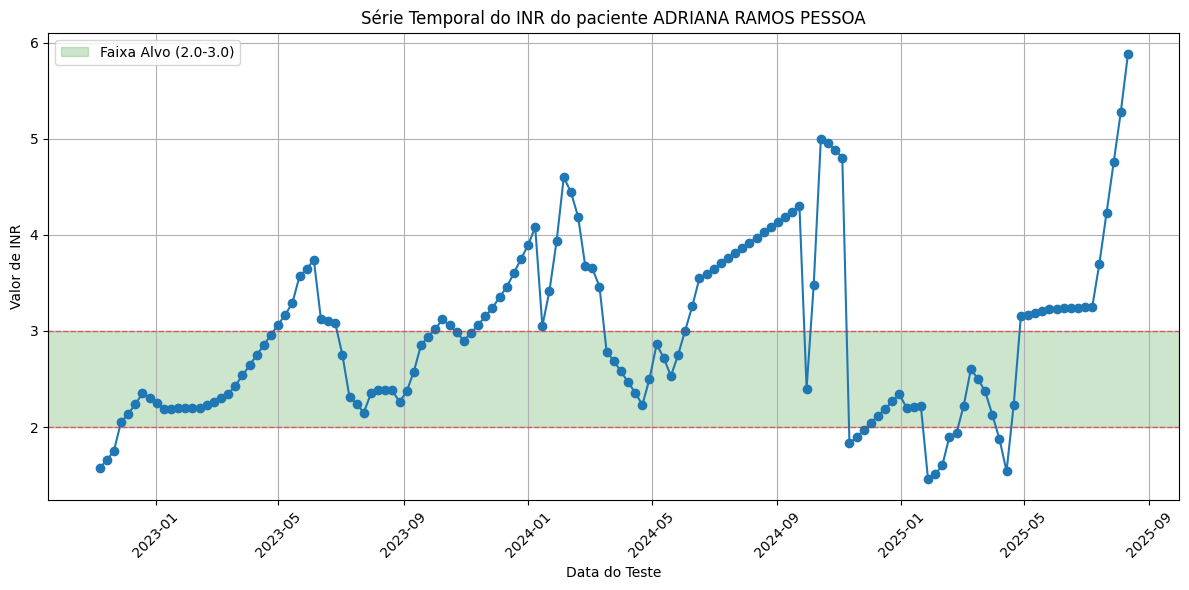

In [9]:
diag = INRModelPlot()

paciente1 = INRDataManipulation(path=path1)
paciente2 = INRDataManipulation(path=path2)
paciente3 = INRDataManipulation(path=path3)
paciente4 = INRDataManipulation(path=path4)

data1 = paciente1.get_data_final()
data2 = paciente2.get_data_final()
data3 = paciente3.get_data_final()
data4 = paciente4.get_data_final()

display(data1['generated'].value_counts())
display(data1)
print(data1.info())

paciente1.plot_inr()

In [4]:
data7 = paciente1.get_data_weekly()
display(data7)

,nome_paciente,test_date,dose_semanal,inr,inr_diff,low_range,high_range,generated,weeks_since_last_real
0,ADRIANA RAMOS PESSOA,2022-10-10,0.0,1.210,0.000,2.0,3.0,0,0
1,ADRIANA RAMOS PESSOA,2022-10-17,20.0,1.430,0.220,2.0,3.0,0,0
2,ADRIANA RAMOS PESSOA,2022-10-24,22.5,1.580,0.150,2.0,3.0,0,0
3,ADRIANA RAMOS PESSOA,2022-10-31,25.0,1.500,-0.080,2.0,3.0,0,0
4,ADRIANA RAMOS PESSOA,2022-11-07,25.0,1.571,0.071,2.0,3.0,1,1
...,...,...,...,...,...,...,...,...,...
144,ADRIANA RAMOS PESSOA,2025-07-14,47.5,3.701,0.451,2.0,3.0,1,1
145,ADRIANA RAMOS PESSOA,2025-07-21,47.5,4.227,0.526,2.0,3.0,1,2
146,ADRIANA RAMOS PESSOA,2025-07-28,47.5,4.753,0.526,2.0,3.0,1,3
147,ADRIANA RAMOS PESSOA,2025-08-04,47.5,5.279,0.526,2.0,3.0,1,4


## Paciente 01

In [75]:
TARGET_COL = "dose_semanal"
DATE_COL = "test_date"
TEST_SIZE_WEEKS = 0.2       
RANDOM_STATE = 42

X1 = data1[features1].copy()
y1 = data1[TARGET_COL].copy()

display(X1.head())
print(X1.info())
print(y1.head())
print(y1.info())

# Separação treino/teste 
n_total = len(data1)
n_test = int(n_total * TEST_SIZE_WEEKS)
n_train = n_total - n_test
if n_test < 1:
    raise ValueError("Teste muito pequeno: aumente TEST_SIZE_WEEKS")

X_train1, X_test1 = X1.iloc[:n_train], X1.iloc[n_train:]
y_train1, y_test1 = y1.iloc[:n_train], y1.iloc[n_train:]
dates_train1 = data1[DATE_COL].iloc[:n_train]
dates_test1 = data1[DATE_COL].iloc[n_train:]

# Proximidade à faixa alvo (usando low/high do próprio df_features)
low_vals1 = data1['low_range'].iloc[n_train:].values
high_vals1 = data1['high_range'].iloc[n_train:].values

print(f"Observações: total={n_total}, train={len(X_train1)}, test={len(X_test1)}")

,inr,generated,weekofyear,month,inr_lag_1,inr_lag_2,inr_lag_3,inr_lag_4,inr_roll_mean_2,inr_roll_mean_4
0,1.571,1,45,11,1.500,1.580,1.430,1.210,1.5400,1.43000
1,1.655,1,46,11,1.571,1.500,1.580,1.430,1.5355,1.52025
2,1.750,0,47,11,1.655,1.571,1.500,1.580,1.6130,1.57650
3,2.050,0,48,11,1.750,1.655,1.571,1.500,1.7025,1.61900
4,2.136,1,49,12,2.050,1.750,1.655,1.571,1.9000,1.75650


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145 entries, 0 to 144
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   inr              145 non-null    float64
 1   generated        145 non-null    int64  
 2   weekofyear       145 non-null    int64  
 3   month            145 non-null    int64  
 4   inr_lag_1        145 non-null    float64
 5   inr_lag_2        145 non-null    float64
 6   inr_lag_3        145 non-null    float64
 7   inr_lag_4        145 non-null    float64
 8   inr_roll_mean_2  145 non-null    float64
 9   inr_roll_mean_4  145 non-null    float64
dtypes: float64(7), int64(3)
memory usage: 11.5 KB
None
0    25.0
1    25.0
2    27.5
3    30.0
4    30.0
Name: dose_semanal, dtype: float64
<class 'pandas.core.series.Series'>
RangeIndex: 145 entries, 0 to 144
Series name: dose_semanal
Non-Null Count  Dtype  
--------------  -----  
145 non-null    float64
dtypes: float64(1)
memory usage: 1

### 1. Treinando XGBoost

In [79]:
# 1. Configuração da Validação Temporal
tscv = TimeSeriesSplit(n_splits=5)

# 2. Definição do Modelo Base com Early Stopping
model_xgb_base = xgb.XGBRegressor(
    random_state=RANDOM_STATE, 
    objective="reg:squarederror",
    early_stopping_rounds=50, 
    eval_metric="mae"
)

# 3. Grade de Parâmetros (Mantida conforme solicitado)
param_grid = {
    "n_estimators": [1000], # Usamos um valor alto, o early_stopping cuidará de reduzir
    "max_depth": [3, 4, 5, 6, 8],
    "learning_rate": [0.03, 0.05, 0.1],
    "subsample": [0.7, 0.9],
    "colsample_bytree": [0.7, 0.9],
    "gamma": [0, 0.1, 0.3, 1, 3],
    "min_child_weight": [1, 3, 5, 8],
    "reg_alpha": [0, 0.01, 0.1, 1],
    "reg_lambda": [1, 3, 10]
}

# 4. Configuração do GridSearchCV
grid_search = GridSearchCV(
    estimator=model_xgb_base,
    param_grid=param_grid,
    cv=tscv,
    scoring="neg_mean_absolute_error",
    verbose=1,
    n_jobs=-1 # Usa todos os núcleos
)

print(f"Iniciando GridSearchCV com {np.prod([len(v) for v in param_grid.values()])} combinações...")
start = time.time()

# No fit do Grid, precisamos passar o eval_set para o Early Stopping funcionar
# Usamos o próprio set de treino; o GridSearchCV fará o fatiamento interno (folds)
grid_search.fit(X_train1, y_train1, eval_set=[(X_train1, y_train1)], verbose=False)

end = time.time()
print(f"Tempo de tuning: {end - start:.2f} segundos")

# 5. Extração dos Melhores Parâmetros
best_params = grid_search.best_params_
print("\n===== MELHORES PARÂMETROS =====")
print(best_params)
print(f"MAE médio (validação cruzada): {-grid_search.best_score_:.4f}")

# 6. Treinamento Final com o melhor modelo
# O GridSearchCV já treina o 'best_estimator_' com todos os dados de X_train1
final_model = grid_search.best_estimator_

# Previsões
y_pred_train1 = final_model.predict(X_train1)
y_pred_test1 = final_model.predict(X_test1)

# 7. Exibição de Métricas Finais
mae_train1 = mean_absolute_error(y_train1, y_pred_train1)
mae_test1 = mean_absolute_error(y_test1, y_pred_test1)
rmse_train1 = np.sqrt(mean_squared_error(y_train1, y_pred_train1))
rmse_test1 = np.sqrt(mean_squared_error(y_test1, y_pred_test1))

print("\n===== RESULTADOS FINAIS =====")
print(f"MAE train: {mae_train1:.4f} | MAE test: {mae_test1:.4f}")
print(f"RMSE train: {rmse_train1:.4f} | RMSE test: {rmse_test1:.4f}")

Iniciando GridSearchCV com 14400 combinações...
Fitting 5 folds for each of 14400 candidates, totalling 72000 fits
Tempo de tuning: 2597.33 segundos

===== MELHORES PARÂMETROS =====
{'colsample_bytree': 0.9, 'gamma': 0, 'learning_rate': 0.05, 'max_depth': 5, 'min_child_weight': 3, 'n_estimators': 1000, 'reg_alpha': 0.1, 'reg_lambda': 10, 'subsample': 0.9}
MAE médio (validação cruzada): 3.0702

===== RESULTADOS FINAIS =====
MAE train: 0.0172 | MAE test: 12.5948
RMSE train: 0.0284 | RMSE test: 13.4075


In [80]:
# Carregar modelo já treinado
# final_model = joblib.load('machines/modelo_xgboost_final.pkl')

# Previsões
y_pred_train1 = final_model.predict(X_train1)
y_pred_test1 = final_model.predict(X_test1)

# Exibição de Métricas Finais
mae_train1 = mean_absolute_error(y_train1, y_pred_train1)
mae_test1 = mean_absolute_error(y_test1, y_pred_test1)
rmse_train1 = np.sqrt(mean_squared_error(y_train1, y_pred_train1))
rmse_test1 = np.sqrt(mean_squared_error(y_test1, y_pred_test1))

print("\n===== RESULTADOS FINAIS =====")
print(f"MAE train: {mae_train1:.4f} | MAE test: {mae_test1:.4f}")
print(f"RMSE train: {rmse_train1:.4f} | RMSE test: {rmse_test1:.4f}")


===== RESULTADOS FINAIS =====
MAE train: 0.0172 | MAE test: 12.5948
RMSE train: 0.0284 | RMSE test: 13.4075


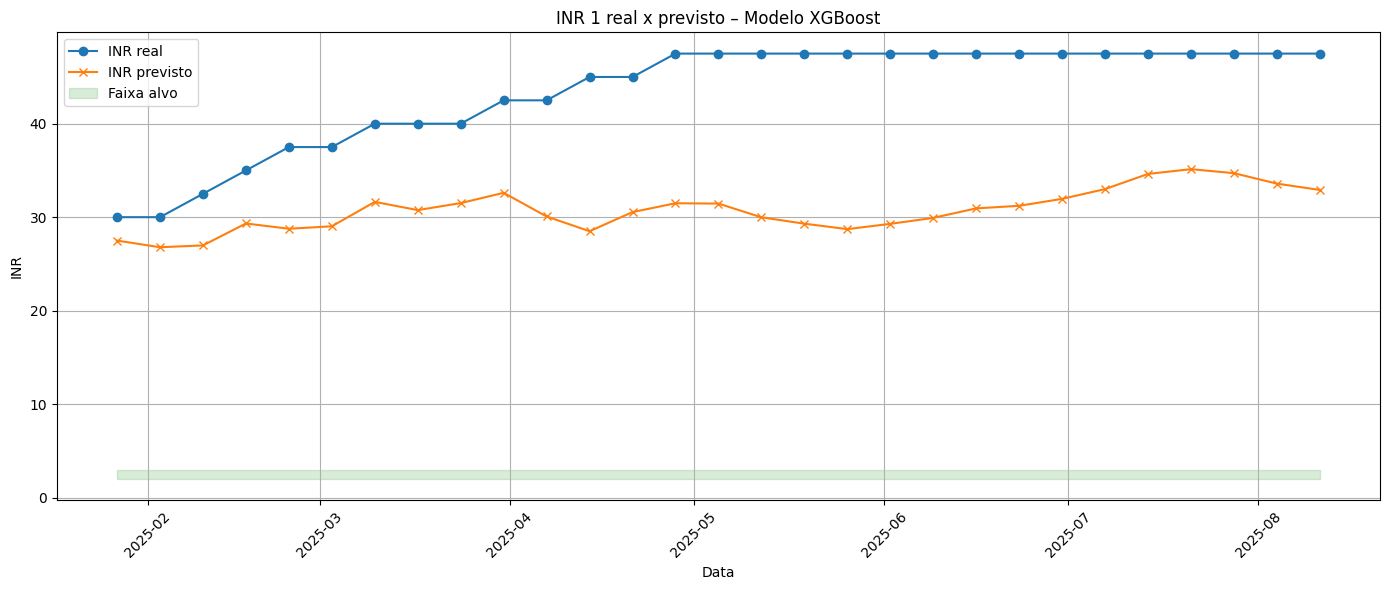

In [81]:
diag.plot_inr_prediction(dates_test1, y_test1.values, y_pred_test1, low_vals1, high_vals1, title="INR 1 real x previsto – Modelo XGBoost")

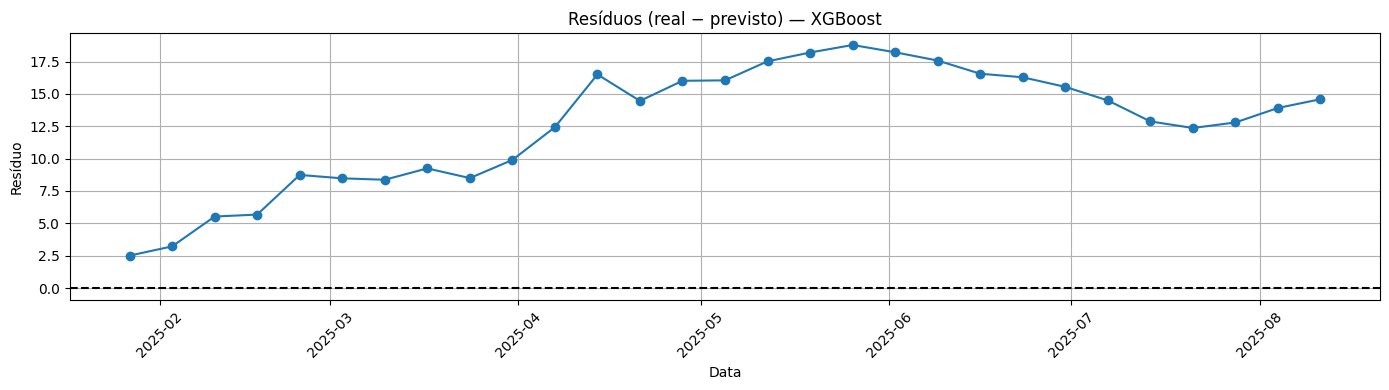

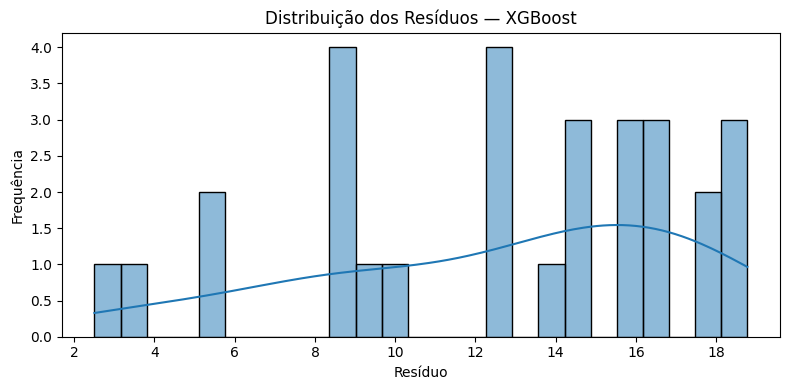

In [82]:
diag.plot_residuals(dates_test1, y_test1.values, y_pred_test1, title="XGBoost")

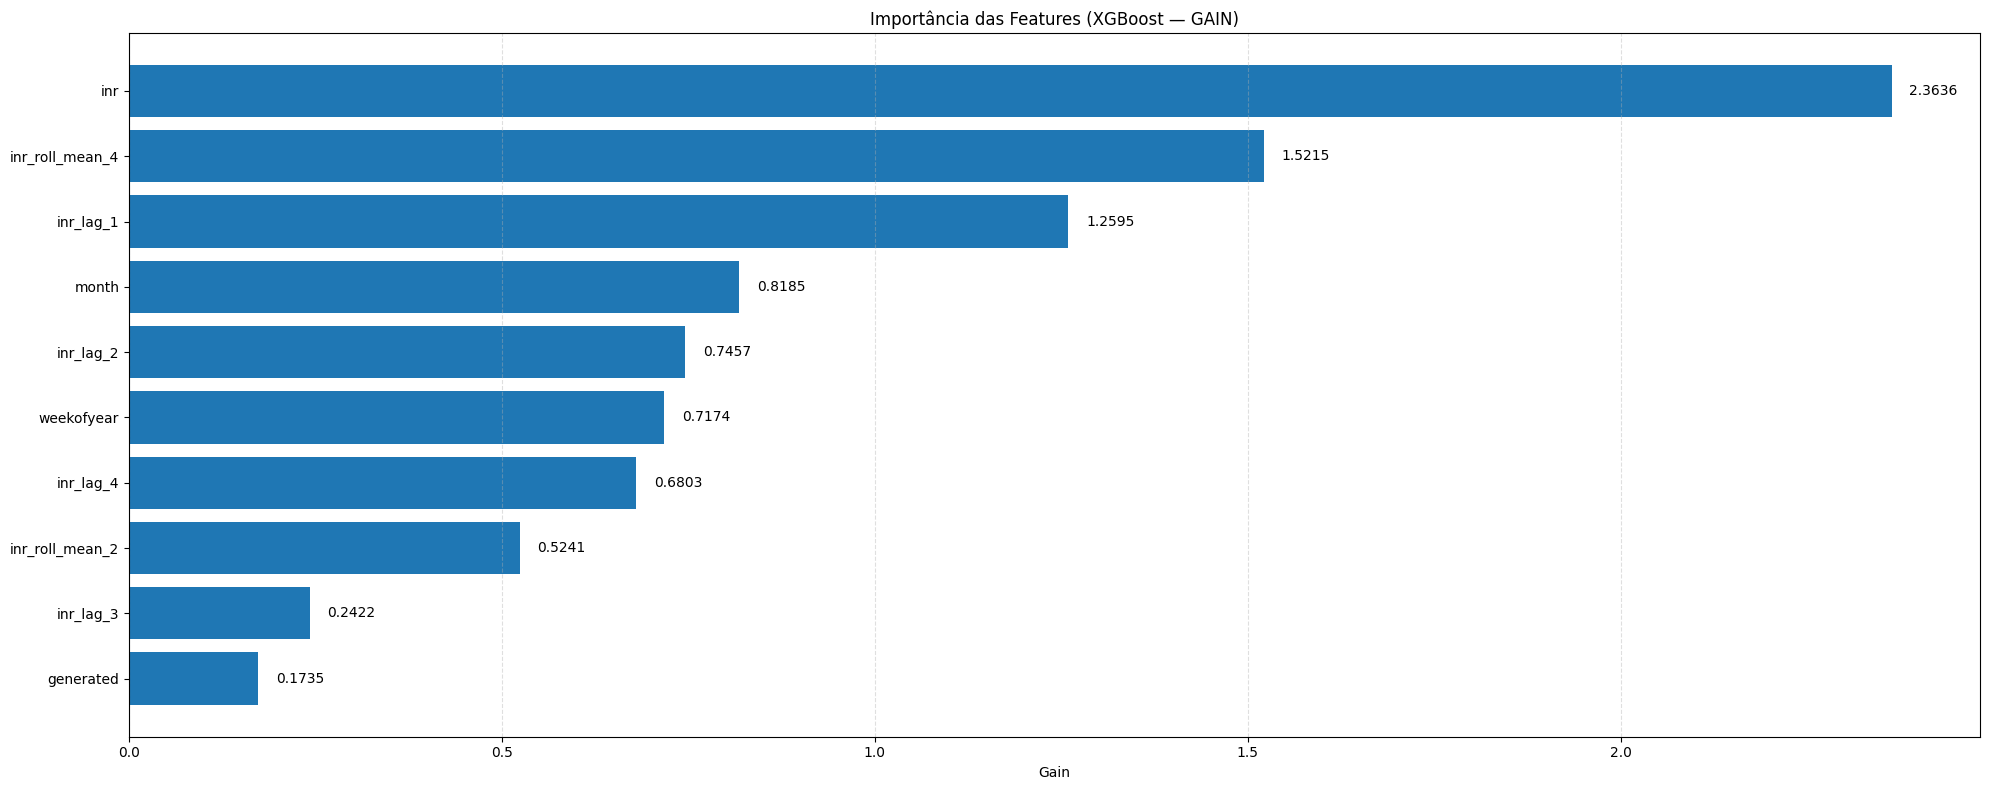

In [83]:
diag.plot_xgb_feature_importance(final_model)

In [ ]:
# Salvando o modelo
joblib.dump(final_model, 'machines/modelo1_xgboost_final.pkl')

# --- Futuramente, para carregar ---
# modelo_carregado = joblib.load('machines/modelo1_xgboost_final.pkl')

# Segunda opção:
# O XGBoost tem um método próprio para isso
# final_model.save_model('machines/modelo1_xgboost_final.json')

# --- Futuramente, para carregar ---
# modelo_carregado = xgb.XGBRegressor()
# modelo_carregado.load_model('machines/modelo1_xgboost_final.json')

['models/modelo_xgboost_final.pkl']

#### Optuna

In [31]:
import optuna
from optuna.samplers import TPESampler
from optuna.pruners import MedianPruner
from sklearn.model_selection import cross_val_score, TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error
import xgboost as xgb
import numpy as np
import pandas as pd
import time

# ===== CONFIGURAÇÃO =====
tscv = TimeSeriesSplit(n_splits=5)
RANDOM_STATE = 42

# ===== FUNÇÃO OBJETIVO PARA XGBOOST =====
def objective_xgb(trial):
    """
    Função objetivo otimizada para XGBoost com Optuna.
    Inclui early stopping e validação temporal.
    """
    
    # ✅ Espaço de busca otimizado para XGBoost
    param = {
        "objective": "reg:squarederror",
        "eval_metric": "mae",
        "random_state": RANDOM_STATE,
        "tree_method": "hist",  # Mais rápido
        "n_jobs": -1,
        
        # Parâmetros estruturais
        "n_estimators": trial.suggest_int("n_estimators", 300, 2000, step=100),
        "max_depth": trial.suggest_int("max_depth", 3, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        
        # Sampling
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "colsample_bylevel": trial.suggest_float("colsample_bylevel", 0.6, 1.0),
        
        # Regularização
        "gamma": trial.suggest_float("gamma", 0.0, 5.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),  # L1
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),  # L2
        
        # XGBoost específicos
        "max_delta_step": trial.suggest_int("max_delta_step", 0, 5),
        "scale_pos_weight": trial.suggest_float("scale_pos_weight", 0.8, 1.2)
    }
    
    # ✅ Cross-validation com TimeSeriesSplit
    model = xgb.XGBRegressor(**param)
    
    scores = cross_val_score(
        model,
        X_train1,
        y_train1,
        cv=tscv,
        scoring="neg_mean_absolute_error",
        n_jobs=-1
    )
    
    mean_score = float(np.mean(scores))
    std_score = float(np.std(scores))
    
    # ✅ Penalizar alta variância (importante para séries temporais)
    # Queremos consistência entre folds
    penalty = 0.1 * std_score  # Ajuste o peso conforme necessário
    adjusted_score = mean_score - penalty
    
    # Logging para debug
    trial.set_user_attr("mean_score", mean_score)
    trial.set_user_attr("std_score", std_score)
    trial.set_user_attr("cv_scores", scores.tolist())
    
    return adjusted_score

In [32]:
# ===== OTIMIZAÇÃO COM OPTUNA =====
print("=" * 70)
print("🔍 OTIMIZAÇÃO XGBOOST COM OPTUNA")
print("=" * 70)

sampler = TPESampler(
    seed=RANDOM_STATE,
    n_startup_trials=15,  # Mais trials iniciais para XGBoost
    multivariate=True
)

pruner = MedianPruner(
    n_startup_trials=5,
    n_warmup_steps=3
)

study_xgb = optuna.create_study(
    direction="maximize",
    sampler=sampler,
    pruner=pruner,
    study_name="xgboost_optimization"
)

start = time.time()

study_xgb.optimize(
    objective_xgb,
    n_trials=100,  # 100 trials
    n_jobs=1,  # 1 trial por vez
    show_progress_bar=True,
    timeout=3600  # 1 hora máximo
)

end = time.time()

print(f"\n⏱️ Tempo de otimização: {(end - start)/60:.2f} minutos")
print(f"🎯 Trials completados: {len(study_xgb.trials)}")
print(f"🎯 Trials podados: {len([t for t in study_xgb.trials if t.state == optuna.trial.TrialState.PRUNED])}")

[I 2026-02-13 06:49:30,013] A new study created in memory with name: xgboost_optimization


🔍 OTIMIZAÇÃO XGBOOST COM OPTUNA


Best trial: 0. Best value: -3.79552:   1%|          | 1/100 [00:03<05:03,  3.07s/it, 3.06/3600 seconds]

[I 2026-02-13 06:49:33,077] Trial 0 finished with value: -3.795516081411304 and parameters: {'n_estimators': 900, 'max_depth': 10, 'learning_rate': 0.1205712628744377, 'min_child_weight': 6, 'subsample': 0.6624074561769746, 'colsample_bytree': 0.662397808134481, 'colsample_bylevel': 0.6232334448672797, 'gamma': 4.330880728874676, 'reg_alpha': 0.002570603566117598, 'reg_lambda': 0.023585940584142682, 'max_delta_step': 0, 'scale_pos_weight': 1.1879639408647977}. Best is trial 0 with value: -3.795516081411304.


Best trial: 1. Best value: -3.58484:   2%|▏         | 2/100 [00:05<04:12,  2.58s/it, 5.30/3600 seconds]

...

[I 2026-02-13 06:49:48,292] Trial 95 finished with value: -3.6958683733430413 and parameters: {'n_estimators': 700, 'max_depth': 6, 'learning_rate': 0.021050835264409137, 'min_child_weight': 4, 'subsample': 0.770184534787446, 'colsample_bytree': 0.9618637347150483, 'colsample_bylevel': 0.9380903159061413, 'gamma': 0.9793304967630068, 'reg_alpha': 8.265647508692884e-07, 'reg_lambda': 1.4970091002817842e-07, 'max_delta_step': 2, 'scale_pos_weight': 1.093091958286674}. Best is trial 45 with value: -3.477540951089351.
[I 2026-02-13 06:49:48,398] Trial 96 finished with value: -3.491785224888562 and parameters: {'n_estimators': 700, 'max_depth': 10, 'learning_rate': 0.02257286637418282, 'min_child_weight': 1, 'subsample': 0.9240794611661959, 'colsample_bytree': 0.8195445838389768, 'colsample_bylevel': 0.6452870049540841, 'gamma': 0.5992759146455083, 'reg_alpha': 2.424047910345752e-07, 'reg_lambda': 6.130436397186702e-06, 'max_delta_step': 2, 'scale_pos_weight': 0.9551762992184959}. Best is t

Best trial: 45. Best value: -3.47754:  99%|█████████▉| 99/100 [00:18<00:00,  9.88it/s, 18.61/3600 seconds]

[I 2026-02-13 06:49:48,533] Trial 97 finished with value: -3.4938310174056646 and parameters: {'n_estimators': 1000, 'max_depth': 8, 'learning_rate': 0.021804993079955565, 'min_child_weight': 1, 'subsample': 0.8979929584704732, 'colsample_bytree': 0.701403841211982, 'colsample_bylevel': 0.6462620787609212, 'gamma': 0.5317889945426313, 'reg_alpha': 5.661861281948537e-08, 'reg_lambda': 0.03995862712946255, 'max_delta_step': 1, 'scale_pos_weight': 0.8669994476808058}. Best is trial 45 with value: -3.477540951089351.
[I 2026-02-13 06:49:48,628] Trial 98 finished with value: -3.6447473587207173 and parameters: {'n_estimators': 900, 'max_depth': 5, 'learning_rate': 0.02308249988422175, 'min_child_weight': 5, 'subsample': 0.8226186441222597, 'colsample_bytree': 0.6777967820540057, 'colsample_bylevel': 0.6318144346842054, 'gamma': 1.4068431520046727, 'reg_alpha': 3.590161757118815e-07, 'reg_lambda': 0.003085346887102661, 'max_delta_step': 0, 'scale_pos_weight': 0.8177453181614681}. Best is tri

Best trial: 45. Best value: -3.47754: 100%|██████████| 100/100 [00:18<00:00,  5.34it/s, 18.72/3600 seconds]

[I 2026-02-13 06:49:48,733] Trial 99 finished with value: -3.6479419105724036 and parameters: {'n_estimators': 800, 'max_depth': 8, 'learning_rate': 0.022172310691013594, 'min_child_weight': 1, 'subsample': 0.9204906738249844, 'colsample_bytree': 0.7575986445111871, 'colsample_bylevel': 0.671050361474369, 'gamma': 0.8178243433178599, 'reg_alpha': 6.387563809113633e-06, 'reg_lambda': 9.514775909188115, 'max_delta_step': 3, 'scale_pos_weight': 0.8589641774993424}. Best is trial 45 with value: -3.477540951089351.

⏱️ Tempo de otimização: 0.31 minutos
🎯 Trials completados: 100
🎯 Trials podados: 0


In [33]:
# ===== RESULTADOS =====
print("\n" + "=" * 70)
print("✅ MELHORES RESULTADOS")
print("=" * 70)
print(f"📊 Melhor score ajustado: {study_xgb.best_value:.4f}")
print(f"📊 MAE médio (CV): {-study_xgb.best_trial.user_attrs['mean_score']:.4f}")
print(f"📊 Desvio padrão (CV): {study_xgb.best_trial.user_attrs['std_score']:.4f}")

best_params_xgb = study_xgb.best_trial.params.copy()
print("\n🎯 Melhores Hiperparâmetros:")
for param, value in sorted(best_params_xgb.items()):
    print(f"  • {param}: {value}")

# ===== IMPORTÂNCIA DOS PARÂMETROS =====
print("\n📈 Importância dos Hiperparâmetros (Top 5):")
try:
    param_importance = optuna.importance.get_param_importances(study_xgb)
    for param, importance in sorted(param_importance.items(), key=lambda x: x[1], reverse=True)[:5]:
        print(f"  • {param}: {importance:.4f}")
except:
    print("  (Necessário ≥2 trials)")


✅ MELHORES RESULTADOS
📊 Melhor score ajustado: -3.4775
📊 MAE médio (CV): 3.2678
📊 Desvio padrão (CV): 2.0969

🎯 Melhores Hiperparâmetros:
  • colsample_bylevel: 0.7842638795042527
  • colsample_bytree: 0.7462712645477023
  • gamma: 0.0014985972134226033
  • learning_rate: 0.03962075983235193
  • max_delta_step: 0
  • max_depth: 9
  • min_child_weight: 2
  • n_estimators: 1300
  • reg_alpha: 4.9685276882306595e-05
  • reg_lambda: 2.697242820490083e-06
  • scale_pos_weight: 0.8968964994058687
  • subsample: 0.6826544670179524

📈 Importância dos Hiperparâmetros (Top 5):
  • gamma: 0.2779
  • min_child_weight: 0.2092
  • learning_rate: 0.1786
  • colsample_bylevel: 0.0831
  • subsample: 0.0777


In [34]:
# ===== TREINAMENTO FINAL =====
print("\n" + "=" * 70)
print("🏋️ TREINAMENTO DO MODELO FINAL")
print("=" * 70)

# Split de validação
split_idx = int(len(X_train1) * 0.8)
X_train_final = X_train1.iloc[:split_idx]
y_train_final = y_train1.iloc[:split_idx]
X_val = X_train1.iloc[split_idx:]
y_val = y_train1.iloc[split_idx:]

# ✅ Modelo final com early stopping
final_params_xgb = {
    "objective": "reg:squarederror",
    "eval_metric": "mae",
    "random_state": RANDOM_STATE,
    "tree_method": "hist",
    "n_jobs": -1,
    "early_stopping_rounds": 50,  # Early stopping
    **best_params_xgb
}

model_xgb = xgb.XGBRegressor(**final_params_xgb)

print("🎯 Treinando com early stopping...")
model_xgb.fit(
    X_train_final,
    y_train_final,
    eval_set=[(X_val, y_val)],
    verbose=100
)

print(f"\n🛑 Best iteration: {model_xgb.best_iteration}")
print(f"🌳 Árvores usadas: {model_xgb.best_iteration} / {final_params_xgb['n_estimators']}")



🏋️ TREINAMENTO DO MODELO FINAL
🎯 Treinando com early stopping...
[0]	validation_0-mae:2.19571


[72]	validation_0-mae:2.15581

🛑 Best iteration: 22
🌳 Árvores usadas: 22 / 1300


In [35]:
# ===== PREVISÕES =====
y_pred_train_xgb = model_xgb.predict(X_train1)
y_pred_test_xgb = model_xgb.predict(X_test1)

# ===== MÉTRICAS =====
mae_train_xgb = mean_absolute_error(y_train1, y_pred_train_xgb)
mae_test_xgb = mean_absolute_error(y_test1, y_pred_test_xgb)
rmse_train_xgb = np.sqrt(mean_squared_error(y_train1, y_pred_train_xgb))
rmse_test_xgb = np.sqrt(mean_squared_error(y_test1, y_pred_test_xgb))

print("\n" + "=" * 70)
print("📊 RESULTADOS FINAIS - XGBOOST")
print("=" * 70)
print(f"MAE  → Train: {mae_train_xgb:.4f} | Test: {mae_test_xgb:.4f}")
print(f"RMSE → Train: {rmse_train_xgb:.4f} | Test: {rmse_test_xgb:.4f}")
print(f"Gap MAE: {((mae_test_xgb - mae_train_xgb)/mae_train_xgb * 100):+.2f}%")
print(f"Gap RMSE: {((rmse_test_xgb - rmse_train_xgb)/rmse_train_xgb * 100):+.2f}%")
print("=" * 70)


📊 RESULTADOS FINAIS - XGBOOST
MAE  → Train: 1.5427 | Test: 11.6196
RMSE → Train: 1.7580 | Test: 12.5435
Gap MAE: +653.20%
Gap RMSE: +613.51%


### 2. Treinando LightGBM

In [36]:
# ===== CONFIGURAÇÃO =====
tscv = TimeSeriesSplit(n_splits=5)

base_params = {
    "objective": "regression",
    "metric": "mae",
    "random_state": RANDOM_STATE,
    "verbosity": -1,
    "n_jobs": -1,
    "boosting_type": "gbdt",
    "force_col_wise": True
}

# ========================================================================
# ETAPA 1: BUSCA DOS HIPERPARÂMETROS PRINCIPAIS (ESTRUTURA DA ÁRVORE)
# ========================================================================
print("=" * 70)
print("📍 ETAPA 1: Busca de Hiperparâmetros Principais")
print("=" * 70)

param_grid_stage1 = {
    "n_estimators": [500, 1000],
    "learning_rate": [0.03, 0.05, 0.1],
    "num_leaves": [31, 63, 127],
    "max_depth": [-1, 7, 10],
    "min_child_samples": [10, 20, 30]
}

# Calcular número de combinações
n_combinations_stage1 = np.prod([len(v) for v in param_grid_stage1.values()])
print(f"🔢 Número de combinações: {n_combinations_stage1}")
print(f"⏱️ Tempo estimado: {n_combinations_stage1 * 5 / 60:.1f} - {n_combinations_stage1 * 10 / 60:.1f} minutos\n")

lgb_model_stage1 = lgb.LGBMRegressor(**base_params)

grid_search_stage1 = GridSearchCV(
    estimator=lgb_model_stage1,
    param_grid=param_grid_stage1,
    cv=tscv,
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
    verbose=2
)

start_stage1 = time.time()
grid_search_stage1.fit(X_train1, y_train1)
end_stage1 = time.time()

best_params_stage1 = grid_search_stage1.best_params_
best_score_stage1 = -grid_search_stage1.best_score_

print("\n" + "=" * 70)
print("✅ RESULTADOS DA ETAPA 1")
print("=" * 70)
print(f"⏱️ Tempo: {(end_stage1 - start_stage1)/60:.2f} minutos")
print(f"📊 Melhor MAE (CV): {best_score_stage1:.4f}\n")
print("🎯 Melhores Parâmetros da Etapa 1:")
for param, value in best_params_stage1.items():
    print(f"  • {param}: {value}")
print()

📍 ETAPA 1: Busca de Hiperparâmetros Principais
🔢 Número de combinações: 162
⏱️ Tempo estimado: 13.5 - 27.0 minutos

Fitting 5 folds for each of 162 candidates, totalling 810 fits

✅ RESULTADOS DA ETAPA 1
⏱️ Tempo: 2.08 minutos
📊 Melhor MAE (CV): 3.4139

🎯 Melhores Parâmetros da Etapa 1:
  • learning_rate: 0.1
  • max_depth: -1
  • min_child_samples: 20
  • n_estimators: 1000
  • num_leaves: 31



In [37]:
# ========================================================================
# ETAPA 2: REFINAMENTO DE REGULARIZAÇÃO E SAMPLING
# ========================================================================
print("=" * 70)
print("📍 ETAPA 2: Refinamento de Regularização e Sampling")
print("=" * 70)

param_grid_stage2 = {
    "subsample": [0.7, 0.8, 0.9],
    "colsample_bytree": [0.7, 0.8, 0.9],
    "reg_alpha": [0.0, 0.01, 0.1, 1.0],
    "reg_lambda": [0.0, 0.01, 0.1, 1.0],
    "min_split_gain": [0.0, 0.01, 0.1]
}

# Calcular número de combinações
n_combinations_stage2 = np.prod([len(v) for v in param_grid_stage2.values()])
print(f"🔢 Número de combinações: {n_combinations_stage2}")
print(f"⏱️ Tempo estimado: {n_combinations_stage2 * 5 / 60:.1f} - {n_combinations_stage2 * 10 / 60:.1f} minutos\n")

# Criar modelo com os melhores parâmetros da Etapa 1
lgb_model_stage2 = lgb.LGBMRegressor(**{**base_params, **best_params_stage1})

grid_search_stage2 = GridSearchCV(
    estimator=lgb_model_stage2,
    param_grid=param_grid_stage2,
    cv=tscv,
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
    verbose=2
)

start_stage2 = time.time()
grid_search_stage2.fit(X_train1, y_train1)
end_stage2 = time.time()

best_params_stage2 = grid_search_stage2.best_params_
best_score_stage2 = -grid_search_stage2.best_score_

print("\n" + "=" * 70)
print("✅ RESULTADOS DA ETAPA 2")
print("=" * 70)
print(f"⏱️ Tempo: {(end_stage2 - start_stage2)/60:.2f} minutos")
print(f"📊 Melhor MAE (CV): {best_score_stage2:.4f}\n")
print("🎯 Melhores Parâmetros da Etapa 2:")
for param, value in best_params_stage2.items():
    print(f"  • {param}: {value}")
print()

📍 ETAPA 2: Refinamento de Regularização e Sampling
🔢 Número de combinações: 432
⏱️ Tempo estimado: 36.0 - 72.0 minutos

Fitting 5 folds for each of 432 candidates, totalling 2160 fits

✅ RESULTADOS DA ETAPA 2
⏱️ Tempo: 3.44 minutos
📊 Melhor MAE (CV): 3.3515

🎯 Melhores Parâmetros da Etapa 2:
  • colsample_bytree: 0.7
  • min_split_gain: 0.01
  • reg_alpha: 0.1
  • reg_lambda: 0.1
  • subsample: 0.7



In [38]:
# ========================================================================
# COMBINAÇÃO FINAL DOS PARÂMETROS
# ========================================================================
final_params = {**base_params, **best_params_stage1, **best_params_stage2}

print("=" * 70)
print("🎯 PARÂMETROS FINAIS COMBINADOS")
print("=" * 70)
for param, value in final_params.items():
    print(f"  • {param}: {value}")

total_time = (end_stage1 - start_stage1 + end_stage2 - start_stage2) / 60
print(f"\n⏱️ Tempo Total de Tuning: {total_time:.2f} minutos")
print(f"📊 Melhoria MAE: {best_score_stage1:.4f} → {best_score_stage2:.4f} ({((best_score_stage2 - best_score_stage1)/best_score_stage1 * 100):+.2f}%)")
print()

🎯 PARÂMETROS FINAIS COMBINADOS
  • objective: regression
  • metric: mae
  • random_state: 42
  • verbosity: -1
  • n_jobs: -1
  • boosting_type: gbdt
  • force_col_wise: True
  • learning_rate: 0.1
  • max_depth: -1
  • min_child_samples: 20
  • n_estimators: 1000
  • num_leaves: 31
  • colsample_bytree: 0.7
  • min_split_gain: 0.01
  • reg_alpha: 0.1
  • reg_lambda: 0.1
  • subsample: 0.7

⏱️ Tempo Total de Tuning: 5.53 minutos
📊 Melhoria MAE: 3.4139 → 3.3515 (-1.83%)



In [39]:
# ========================================================================
# TREINAMENTO FINAL COM EARLY STOPPING
# ========================================================================
print("=" * 70)
print("🏋️ TREINAMENTO DO MODELO FINAL")
print("=" * 70)

# Criar split temporal para validação (early stopping)
split_idx = int(len(X_train1) * 0.8)
X_train_final = X_train1.iloc[:split_idx]
y_train_final = y_train1.iloc[:split_idx]
X_val = X_train1.iloc[split_idx:]
y_val = y_train1.iloc[split_idx:]

print(f"📊 Split de dados:")
print(f"  • Treino final: {len(X_train_final)} amostras ({len(X_train_final)/len(X_train1)*100:.1f}%)")
print(f"  • Validação: {len(X_val)} amostras ({len(X_val)/len(X_train1)*100:.1f}%)")
print(f"  • Teste: {len(X_test1)} amostras\n")

# Treinar modelo final
model_lgb = lgb.LGBMRegressor(**final_params)

print("🎯 Iniciando treinamento com early stopping...")
start_final = time.time()

model_lgb.fit(
    X_train_final, 
    y_train_final,
    eval_set=[(X_val, y_val)],
    eval_metric="mae",
    callbacks=[
        lgb.early_stopping(stopping_rounds=50, verbose=False),
        lgb.log_evaluation(period=100)
    ]
)

end_final = time.time()
print(f"\n⏱️ Tempo de treinamento final: {(end_final - start_final):.2f} segundos")
print(f"🛑 Melhor iteração (early stopping): {model_lgb.best_iteration_}")
print(f"🌳 Total de árvores utilizadas: {model_lgb.best_iteration_} / {final_params['n_estimators']}")
print()

🏋️ TREINAMENTO DO MODELO FINAL
📊 Split de dados:
  • Treino final: 92 amostras (79.3%)
  • Validação: 24 amostras (20.7%)
  • Teste: 29 amostras

🎯 Iniciando treinamento com early stopping...

⏱️ Tempo de treinamento final: 0.20 segundos
🛑 Melhor iteração (early stopping): 7
🌳 Total de árvores utilizadas: 7 / 1000



In [40]:
# ========================================================================
# AVALIAÇÃO FINAL
# ========================================================================
print("=" * 70)
print("📊 AVALIAÇÃO FINAL DO MODELO")
print("=" * 70)

# Previsões usando a melhor iteração
y_pred_train1 = model_lgb.predict(X_train1, num_iteration=model_lgb.best_iteration_)
y_pred_test1 = model_lgb.predict(X_test1, num_iteration=model_lgb.best_iteration_)

# Métricas
mae_train1 = mean_absolute_error(y_train1, y_pred_train1)
mae_test1 = mean_absolute_error(y_test1, y_pred_test1)
rmse_train1 = np.sqrt(mean_squared_error(y_train1, y_pred_train1))
rmse_test1 = np.sqrt(mean_squared_error(y_test1, y_pred_test1))

# Calcular gaps
mae_gap = ((mae_test1 - mae_train1) / mae_train1 * 100)
rmse_gap = ((rmse_test1 - rmse_train1) / rmse_train1 * 100)

print("\n📈 MÉTRICAS FINAIS")
print("-" * 70)
print(f"{'Métrica':<15} {'Train':>12} {'Test':>12} {'Gap':>12}")
print("-" * 70)
print(f"{'MAE':<15} {mae_train1:>12.4f} {mae_test1:>12.4f} {mae_gap:>11.2f}%")
print(f"{'RMSE':<15} {rmse_train1:>12.4f} {rmse_test1:>12.4f} {rmse_gap:>11.2f}%")
print("-" * 70)

# Diagnóstico de overfitting
if mae_gap < 5:
    print("✅ Modelo bem generalizado (gap < 5%)")
elif mae_gap < 10:
    print("⚠️ Leve overfitting (5% < gap < 10%)")
else:
    print("❌ Overfitting significativo (gap > 10%)")

print("\n" + "=" * 70)
print("🎉 TUNAGEM CONCLUÍDA COM SUCESSO!")
print("=" * 70)

📊 AVALIAÇÃO FINAL DO MODELO

📈 MÉTRICAS FINAIS
----------------------------------------------------------------------
Métrica                Train         Test          Gap
----------------------------------------------------------------------
MAE                   2.0663      10.8712      426.11%
RMSE                  2.3955      11.7819      391.82%
----------------------------------------------------------------------
❌ Overfitting significativo (gap > 10%)

🎉 TUNAGEM CONCLUÍDA COM SUCESSO!


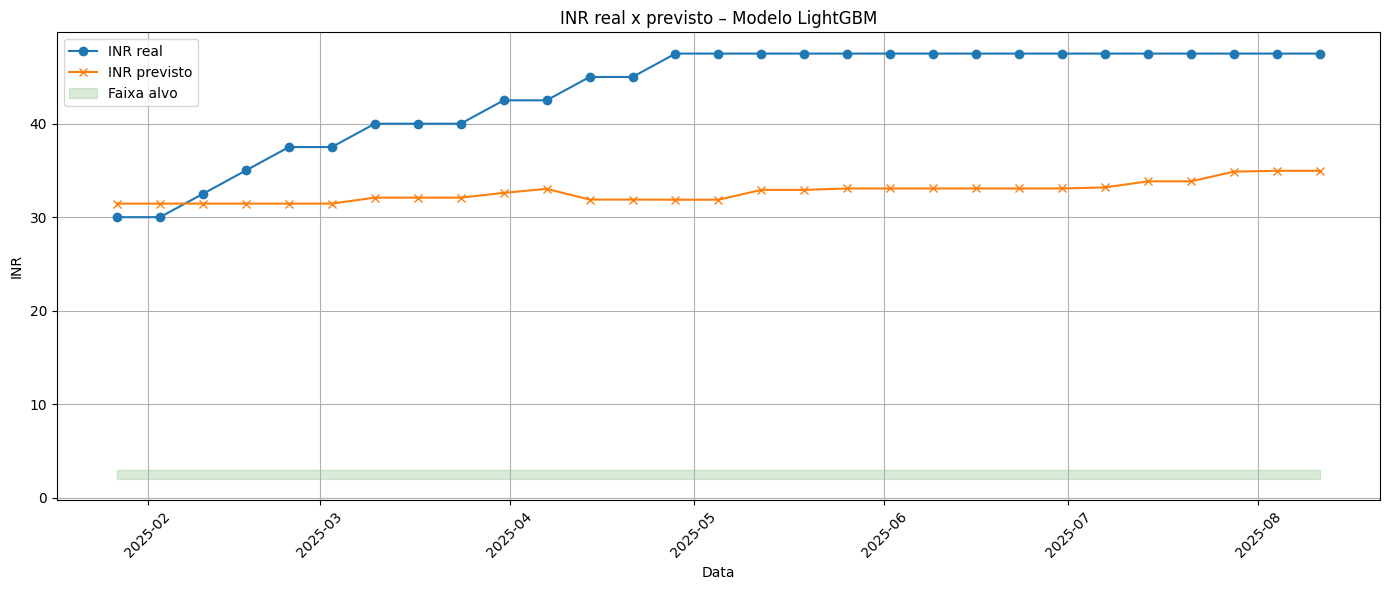

In [41]:
diag.plot_inr_prediction(dates_test1, y_test1.values, y_pred_test1, low_vals1, high_vals1, title="INR real x previsto – Modelo LightGBM")

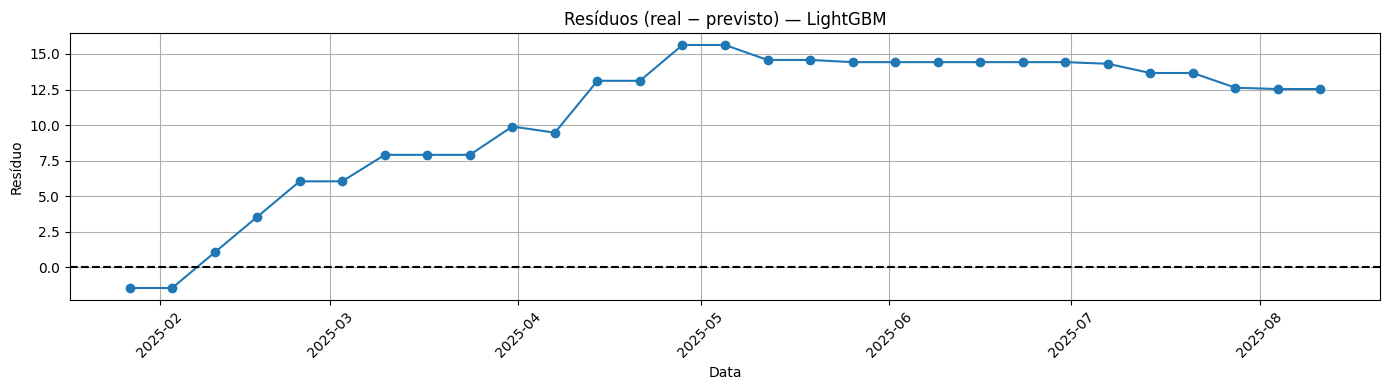

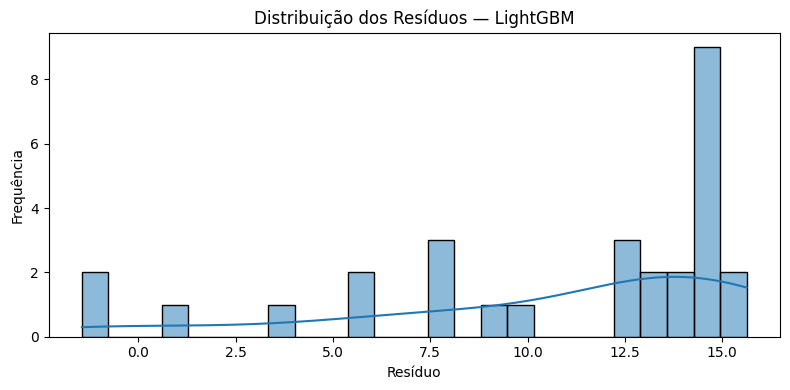

In [42]:
diag.plot_residuals(dates_test1, y_test1.values, y_pred_test1, title="LightGBM")

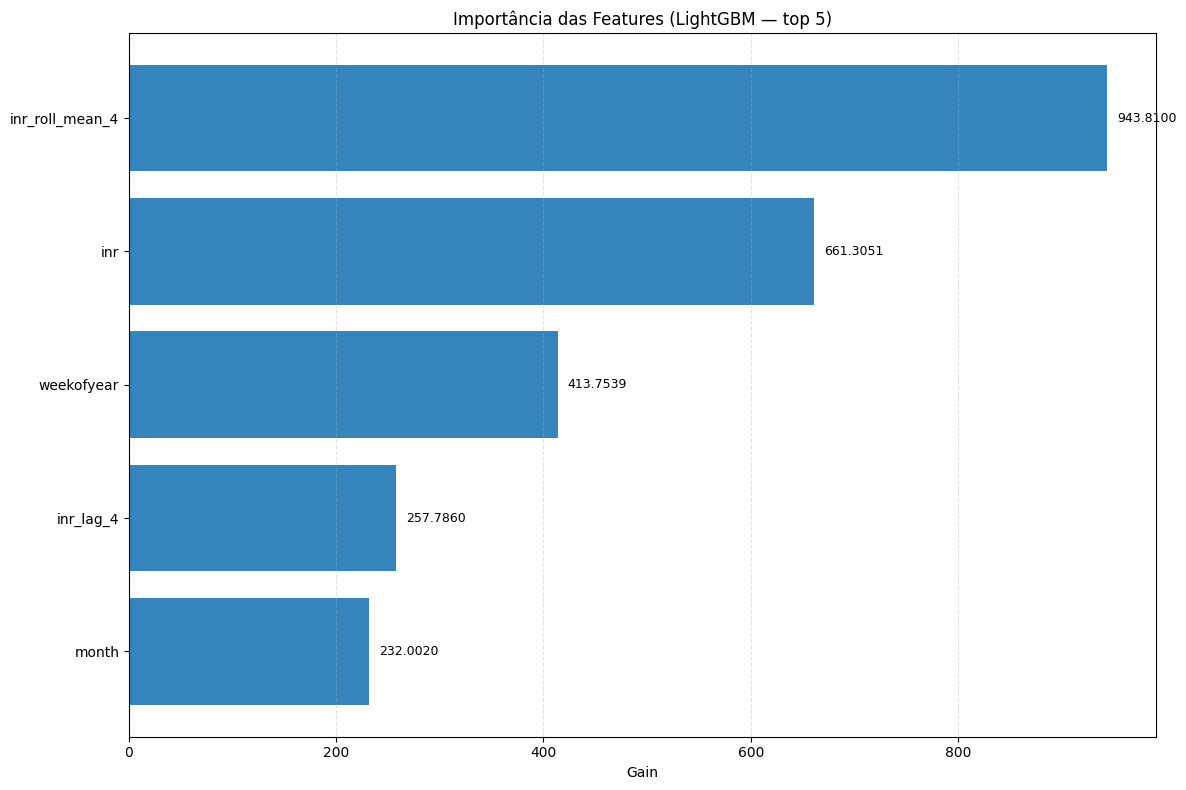

In [43]:
diag.plot_lgb_feature_importance(model_lgb, feature_names=features1)

#### Optuna

In [44]:
import optuna
from optuna.samplers import TPESampler
from optuna.pruners import MedianPruner

# ===== CONFIGURAÇÃO =====
tscv = TimeSeriesSplit(n_splits=5)
RANDOM_STATE = 42  # Ajuste conforme seu código

# ===== FUNÇÃO OBJETIVO OTIMIZADA =====
def objective(trial):
    """
    Função objetivo para otimização com Optuna.
    Retorna neg_mae médio do cross-validation.
    """
    
    # ✅ Espaço de busca otimizado
    param = {
        "objective": "regression",
        "metric": "mae",
        "verbosity": -1,
        "random_state": RANDOM_STATE,
        "n_jobs": -1,  # ✅ Paralelização no LightGBM
        "force_col_wise": True,
        "boosting_type": "gbdt",
        
        # Parâmetros estruturais
        "n_estimators": trial.suggest_int("n_estimators", 300, 1500, step=100),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),  # ✅ Corrigido
        "num_leaves": trial.suggest_int("num_leaves", 15, 127),
        "max_depth": trial.suggest_int("max_depth", 3, 12),
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 50),
        
        # Regularização
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "subsample_freq": 1,  # Ativar subsampling
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),  # ✅ Corrigido
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),  # ✅ Corrigido
        "min_split_gain": trial.suggest_float("min_split_gain", 0.0, 0.5)
    }
    
    # ✅ Cross-validation com TimeSeriesSplit
    model = lgb.LGBMRegressor(**param)
    
    # Scoring negativo MAE (quanto maior, melhor)
    scores = cross_val_score(
        model, 
        X_train1,  # Ajuste para seu dataset
        y_train1, 
        cv=tscv, 
        scoring="neg_mean_absolute_error", 
        n_jobs=-1  # ✅ Paralelização no CV
    )
    
    # Retornar média dos scores (Optuna vai maximizar)
    mean_score = float(np.mean(scores))
    
    # ✅ Logging opcional para acompanhamento
    trial.set_user_attr("std_score", float(np.std(scores)))
    
    return mean_score

In [45]:
# ===== CONFIGURAÇÃO DO ESTUDO OPTUNA =====
print("=" * 70)
print("🔍 INICIANDO OTIMIZAÇÃO COM OPTUNA")
print("=" * 70)

# ✅ Sampler otimizado com pruning
sampler = TPESampler(
    seed=RANDOM_STATE,
    n_startup_trials=10,  # Trials aleatórios iniciais
    multivariate=True  # Considera correlações entre parâmetros
)

# ✅ Pruner para interromper trials ruins cedo
pruner = MedianPruner(
    n_startup_trials=5,  # Não fazer pruning nos primeiros 5 trials
    n_warmup_steps=3  # Esperar 3 folds antes de pruning
)

study = optuna.create_study(
    direction="maximize",  # Maximizar neg_mae
    sampler=sampler,
    pruner=pruner,
    study_name="lightgbm_optimization"
)

# ✅ Otimização com mais trials e timeout
start = time.time()

study.optimize(
    objective, 
    n_trials=100,  # ✅ Aumentado para 100 trials
    n_jobs=1,  # ✅ 1 trial por vez (evita conflito com n_jobs do CV)
    show_progress_bar=True,
    timeout=3600  # ✅ Timeout de 1 hora (opcional)
)

end = time.time()

print(f"\n⏱️ Tempo total de otimização: {(end - start)/60:.2f} minutos")
print(f"🎯 Número de trials completados: {len(study.trials)}")
print(f"🎯 Número de trials podados: {len([t for t in study.trials if t.state == optuna.trial.TrialState.PRUNED])}")

[I 2026-02-13 06:55:28,324] A new study created in memory with name: lightgbm_optimization


🔍 INICIANDO OTIMIZAÇÃO COM OPTUNA


  0%|          | 0/100 [00:00<?, ?it/s]

Best trial: 0. Best value: -3.57753:   1%|          | 1/100 [00:02<04:07,  2.50s/it, 2.49/3600 seconds]

[I 2026-02-13 06:55:30,812] Trial 0 finished with value: -3.577527341192232 and parameters: {'n_estimators': 700, 'learning_rate': 0.17254716573280354, 'num_leaves': 97, 'max_depth': 8, 'min_child_samples': 12, 'subsample': 0.662397808134481, 'colsample_bytree': 0.6232334448672797, 'reg_alpha': 0.6245760287469893, 'reg_lambda': 0.002570603566117598, 'min_split_gain': 0.35403628889802274}. Best is trial 0 with value: -3.577527341192232.


...

[I 2026-02-13 06:56:25,750] Trial 96 finished with value: -3.5097374110393966 and parameters: {'n_estimators': 1100, 'learning_rate': 0.03742674719400664, 'num_leaves': 93, 'max_depth': 10, 'min_child_samples': 25, 'subsample': 0.6973285390059006, 'colsample_bytree': 0.8564074741779941, 'reg_alpha': 0.1219416691405716, 'reg_lambda': 9.558639836206231e-08, 'min_split_gain': 0.2963873651514628}. Best is trial 30 with value: -2.909495630850888.


Best trial: 30. Best value: -2.9095:  98%|█████████▊| 98/100 [00:57<00:00,  3.44it/s, 57.71/3600 seconds]

[I 2026-02-13 06:56:26,055] Trial 97 finished with value: -3.666260849551604 and parameters: {'n_estimators': 800, 'learning_rate': 0.027574516354449383, 'num_leaves': 86, 'max_depth': 8, 'min_child_samples': 20, 'subsample': 0.6477059553655519, 'colsample_bytree': 0.8931851054392628, 'reg_alpha': 2.628239386000281e-05, 'reg_lambda': 1.8955986745091148e-06, 'min_split_gain': 0.2339494996548906}. Best is trial 30 with value: -2.909495630850888.


Best trial: 30. Best value: -2.9095: 100%|██████████| 100/100 [00:58<00:00,  1.72it/s, 58.09/3600 seconds]

[I 2026-02-13 06:56:26,284] Trial 98 finished with value: -3.3055853404825393 and parameters: {'n_estimators': 700, 'learning_rate': 0.09397162219719275, 'num_leaves': 52, 'max_depth': 12, 'min_child_samples': 29, 'subsample': 0.7259392467828913, 'colsample_bytree': 0.7645223116395564, 'reg_alpha': 1.531004550201267e-08, 'reg_lambda': 1.4289827780959636e-08, 'min_split_gain': 0.018059876247528556}. Best is trial 30 with value: -2.909495630850888.
[I 2026-02-13 06:56:26,432] Trial 99 finished with value: -2.9965528424312544 and parameters: {'n_estimators': 400, 'learning_rate': 0.028764623726764346, 'num_leaves': 65, 'max_depth': 12, 'min_child_samples': 28, 'subsample': 0.6972676850824526, 'colsample_bytree': 0.8261322485012687, 'reg_alpha': 3.32779273082708e-07, 'reg_lambda': 1.844263459883256e-08, 'min_split_gain': 0.013830738924055529}. Best is trial 30 with value: -2.909495630850888.

⏱️ Tempo total de otimização: 0.97 minutos
🎯 Número de trials completados: 100
🎯 Número de trials 

In [46]:
# ===== RESULTADOS =====
print("\n" + "=" * 70)
print("✅ MELHORES RESULTADOS")
print("=" * 70)
print(f"📊 Melhor score (neg_mae): {study.best_value:.4f}")
print(f"📊 MAE equivalente: {-study.best_value:.4f}")

optuna_best_params = study.best_trial.params.copy()
print("\n🎯 Melhores Hiperparâmetros:")
for param, value in sorted(optuna_best_params.items()):
    print(f"  • {param}: {value}")

# ✅ Análise de importância dos parâmetros
print("\n📈 Importância dos Hiperparâmetros:")
try:
    param_importance = optuna.importance.get_param_importances(study)
    for param, importance in sorted(param_importance.items(), key=lambda x: x[1], reverse=True)[:5]:
        print(f"  • {param}: {importance:.4f}")
except:
    print("  (Necessário ≥2 trials para calcular importância)")


✅ MELHORES RESULTADOS
📊 Melhor score (neg_mae): -2.9095
📊 MAE equivalente: 2.9095

🎯 Melhores Hiperparâmetros:
  • colsample_bytree: 0.7873164693171578
  • learning_rate: 0.016102985303640446
  • max_depth: 7
  • min_child_samples: 39
  • min_split_gain: 0.04848238654463535
  • n_estimators: 800
  • num_leaves: 112
  • reg_alpha: 0.012642883177741595
  • reg_lambda: 0.825481528795689
  • subsample: 0.9858885983539226

📈 Importância dos Hiperparâmetros:
  • min_child_samples: 0.5210
  • learning_rate: 0.3040
  • n_estimators: 0.0803
  • num_leaves: 0.0296
  • subsample: 0.0255


In [47]:
# ===== TREINAMENTO FINAL COM OS MELHORES PARÂMETROS =====
print("\n" + "=" * 70)
print("🏋️ TREINAMENTO DO MODELO FINAL")
print("=" * 70)

# Criar split de validação para early stopping
split_idx = int(len(X_train1) * 0.8)
X_train_final = X_train1.iloc[:split_idx]
y_train_final = y_train1.iloc[:split_idx]
X_val = X_train1.iloc[split_idx:]
y_val = y_train1.iloc[split_idx:]

# ✅ Combinar parâmetros base + melhores do Optuna
final_params = {
    "objective": "regression",
    "metric": "mae",
    "random_state": RANDOM_STATE,
    "verbosity": -1,
    "n_jobs": -1,
    "force_col_wise": True,
    "boosting_type": "gbdt",
    **optuna_best_params
}

model_lgb = lgb.LGBMRegressor(**final_params)

print("🎯 Treinando modelo final com early stopping...")
model_lgb.fit(
    X_train_final, 
    y_train_final,
    eval_set=[(X_val, y_val)],
    eval_metric="mae",
    callbacks=[
        lgb.early_stopping(stopping_rounds=50, verbose=False),
        lgb.log_evaluation(period=100)
    ]
)

print(f"\n🛑 Best iteration: {model_lgb.best_iteration_}")


🏋️ TREINAMENTO DO MODELO FINAL
🎯 Treinando modelo final com early stopping...
[100]	valid_0's l1: 1.42081

🛑 Best iteration: 137


In [48]:
# ===== PREVISÕES =====
y_pred_train1 = model_lgb.predict(X_train1, num_iteration=model_lgb.best_iteration_)
y_pred_test1 = model_lgb.predict(X_test1, num_iteration=model_lgb.best_iteration_)

# ===== MÉTRICAS FINAIS =====
mae_train1 = mean_absolute_error(y_train1, y_pred_train1)
mae_test1 = mean_absolute_error(y_test1, y_pred_test1)
rmse_train1 = np.sqrt(mean_squared_error(y_train1, y_pred_train1))
rmse_test1 = np.sqrt(mean_squared_error(y_test1, y_pred_test1))

print("\n" + "=" * 70)
print("📊 RESULTADOS FINAIS")
print("=" * 70)
print(f"MAE  → Train: {mae_train1:.4f} | Test: {mae_test1:.4f}")
print(f"RMSE → Train: {rmse_train1:.4f} | Test: {rmse_test1:.4f}")
print(f"Gap MAE: {((mae_test1 - mae_train1)/mae_train1 * 100):+.2f}%")
print(f"Gap RMSE: {((rmse_test1 - rmse_train1)/rmse_train1 * 100):+.2f}%")
print("=" * 70)

# ===== VISUALIZAÇÃO OPTUNA (OPCIONAL) =====
print("\n💡 Para visualizar gráficos do Optuna, execute:")
print("  optuna.visualization.plot_optimization_history(study)")
print("  optuna.visualization.plot_param_importances(study)")
print("  optuna.visualization.plot_parallel_coordinate(study)")


📊 RESULTADOS FINAIS
MAE  → Train: 2.1221 | Test: 10.3799
RMSE → Train: 2.5702 | Test: 11.1271
Gap MAE: +389.13%
Gap RMSE: +332.93%

💡 Para visualizar gráficos do Optuna, execute:
  optuna.visualization.plot_optimization_history(study)
  optuna.visualization.plot_param_importances(study)
  optuna.visualization.plot_parallel_coordinate(study)


#### Testando

In [ ]:
import joblib
import pickle
import json
import os
from datetime import datetime

# ===== CRIAR DIRETÓRIO PARA SALVAR MODELOS =====
MODEL_DIR = "models"
os.makedirs(MODEL_DIR, exist_ok=True)

# Timestamp para versionamento
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
model_name = f"lightgbm_optuna_{timestamp}"

print("=" * 70)
print("💾 SALVANDO MODELO LIGHTGBM")
print("=" * 70)

# ===== 1. SALVAR MODELO LIGHTGBM (3 FORMATOS) =====

# 🔹 Formato 1: Pickle (sklearn-compatible)
model_path_pkl = os.path.join(MODEL_DIR, f"{model_name}.pkl")
joblib.dump(model_lgb, model_path_pkl)
print(f"✅ Modelo salvo (pickle): {model_path_pkl}")

# 🔹 Formato 2: LightGBM nativo (.txt) - Mais leve e portável
model_path_txt = os.path.join(MODEL_DIR, f"{model_name}.txt")
model_lgb.booster_.save_model(model_path_txt)
print(f"✅ Modelo salvo (LightGBM nativo): {model_path_txt}")

# 🔹 Formato 3: JSON (para deploy em outras linguagens)
model_path_json = os.path.join(MODEL_DIR, f"{model_name}.json")
model_lgb.booster_.save_model(model_path_json, num_iteration=model_lgb.best_iteration_)
print(f"✅ Modelo salvo (JSON): {model_path_json}")

# ===== 2. SALVAR HIPERPARÂMETROS =====
params_path = os.path.join(MODEL_DIR, f"{model_name}_params.json")
with open(params_path, 'w') as f:
    json.dump(final_params, f, indent=4)
print(f"✅ Hiperparâmetros salvos: {params_path}")

# ===== 3. SALVAR MÉTRICAS DE PERFORMANCE =====
metrics = {
    "timestamp": timestamp,
    "best_iteration": int(model_lgb.best_iteration_),
    "n_estimators_used": int(model_lgb.best_iteration_),
    "n_estimators_max": int(final_params['n_estimators']),
    "optuna_best_score": float(study.best_value),
    "optuna_mae_cv": float(-study.best_value),
    "metrics": {
        "train": {
            "mae": float(mae_train1),
            "rmse": float(rmse_train1)
        },
        "test": {
            "mae": float(mae_test1),
            "rmse": float(rmse_test1)
        },
        "gaps": {
            "mae_gap_percent": float((mae_test1 - mae_train1) / mae_train1 * 100),
            "rmse_gap_percent": float((rmse_test1 - rmse_train1) / rmse_train1 * 100)
        }
    },
    "data_info": {
        "n_train_samples": int(len(X_train1)),
        "n_test_samples": int(len(X_test1)),
        "n_features": int(X_train1.shape[1])
    }
}

metrics_path = os.path.join(MODEL_DIR, f"{model_name}_metrics.json")
with open(metrics_path, 'w') as f:
    json.dump(metrics, f, indent=4)
print(f"✅ Métricas salvas: {metrics_path}")

# ===== 4. SALVAR IMPORTÂNCIA DAS FEATURES =====
if hasattr(model_lgb, 'feature_importances_'):
    feature_importance = pd.DataFrame({
        'feature': X_train1.columns,
        'importance': model_lgb.feature_importances_
    }).sort_values('importance', ascending=False)
    
    feature_importance_path = os.path.join(MODEL_DIR, f"{model_name}_feature_importance.csv")
    feature_importance.to_csv(feature_importance_path, index=False)
    print(f"✅ Importância das features salva: {feature_importance_path}")
    
    # Mostrar top 10 features
    print("\n📊 Top 10 Features Mais Importantes:")
    print(feature_importance.head(10).to_string(index=False))

# ===== 5. SALVAR ESTUDO OPTUNA COMPLETO =====
optuna_db_path = os.path.join(MODEL_DIR, f"{model_name}_optuna_study.pkl")
joblib.dump(study, optuna_db_path)
print(f"\n✅ Estudo Optuna salvo: {optuna_db_path}")

# ===== 6. SALVAR NOMES DAS FEATURES (para deploy) =====
feature_names_path = os.path.join(MODEL_DIR, f"{model_name}_feature_names.json")
with open(feature_names_path, 'w') as f:
    json.dump(list(X_train1.columns), f, indent=4)
print(f"✅ Nomes das features salvos: {feature_names_path}")

# ===== 7. CRIAR README DO MODELO =====
readme_content = f"""# Modelo LightGBM - {model_name}

## 📊 Informações Gerais
- **Data de Treinamento**: {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}
- **Algoritmo**: LightGBM com otimização Optuna (TPE Sampler)
- **Melhor Iteração**: {model_lgb.best_iteration_}
- **Total de Features**: {X_train1.shape[1]}

## 📈 Métricas de Performance

### Cross-Validation (Optuna)
- **MAE (CV)**: {-study.best_value:.4f}

### Conjunto de Treino
- **MAE**: {mae_train1:.4f}
- **RMSE**: {rmse_train1:.4f}

### Conjunto de Teste
- **MAE**: {mae_test1:.4f}
- **RMSE**: {rmse_test1:.4f}

### Gaps (Overfitting)
- **Gap MAE**: {((mae_test1 - mae_train1) / mae_train1 * 100):+.2f}%
- **Gap RMSE**: {((rmse_test1 - rmse_train1) / rmse_train1 * 100):+.2f}%

## 🎯 Hiperparâmetros Principais
```python
{json.dumps(final_params, indent=4)}
```

## 📁 Arquivos Salvos
- `{model_name}.pkl` - Modelo completo (joblib)
- `{model_name}.txt` - Modelo LightGBM nativo
- `{model_name}.json` - Modelo em JSON
- `{model_name}_params.json` - Hiperparâmetros
- `{model_name}_metrics.json` - Métricas detalhadas
- `{model_name}_feature_importance.csv` - Importância das features
- `{model_name}_feature_names.json` - Lista de features
- `{model_name}_optuna_study.pkl` - Estudo Optuna completo

## 🚀 Como Carregar o Modelo

### Opção 1: Joblib (Recomendado para Python)
```python
import joblib
model = joblib.load('{model_path_pkl}')
predictions = model.predict(X_new)
```

### Opção 2: LightGBM Nativo
```python
import lightgbm as lgb
booster = lgb.Booster(model_file='{model_path_txt}')
predictions = booster.predict(X_new)
```

### Opção 3: JSON (Para outras linguagens)
```python
import lightgbm as lgb
booster = lgb.Booster(model_file='{model_path_json}')
predictions = booster.predict(X_new)
```

## ⚙️ Reprodução
Para reproduzir este modelo:
1. Usar os mesmos hiperparâmetros em `{model_name}_params.json`
2. Usar as mesmas features em `{model_name}_feature_names.json`
3. Random state: {RANDOM_STATE}
"""

readme_path = os.path.join(MODEL_DIR, f"{model_name}_README.md")
with open(readme_path, 'w', encoding='utf-8') as f:
    f.write(readme_content)
print(f"✅ README criado: {readme_path}")

# ===== 8. RESUMO FINAL =====
print("\n" + "=" * 70)
print("🎉 SALVAMENTO CONCLUÍDO COM SUCESSO!")
print("=" * 70)
print(f"\n📁 Todos os arquivos salvos em: {MODEL_DIR}/")
print(f"🏷️ Nome do modelo: {model_name}")
print(f"💾 Tamanho do modelo (pickle): {os.path.getsize(model_path_pkl) / 1024:.2f} KB")
print(f"💾 Tamanho do modelo (txt): {os.path.getsize(model_path_txt) / 1024:.2f} KB")
print("\n📋 Arquivos criados:")
for file in os.listdir(MODEL_DIR):
    if model_name in file:
        file_path = os.path.join(MODEL_DIR, file)
        size_kb = os.path.getsize(file_path) / 1024
        print(f"  • {file} ({size_kb:.2f} KB)")

In [ ]:
import joblib
import lightgbm as lgb
import json
import pandas as pd

# ===== OPÇÃO 1: CARREGAR COM JOBLIB (MAIS SIMPLES) =====
def load_model_joblib(model_path):
    """Carrega modelo salvo com joblib"""
    model = joblib.load(model_path)
    print(f"✅ Modelo carregado: {model_path}")
    return model

# ===== OPÇÃO 2: CARREGAR MODELO LIGHTGBM NATIVO =====
def load_model_native(model_path, feature_names_path):
    """Carrega modelo LightGBM nativo (.txt)"""
    booster = lgb.Booster(model_file=model_path)
    
    # Carregar nomes das features
    with open(feature_names_path, 'r') as f:
        feature_names = json.load(f)
    
    print(f"✅ Modelo nativo carregado: {model_path}")
    print(f"✅ Features carregadas: {len(feature_names)}")
    
    return booster, feature_names

# ===== OPÇÃO 3: CARREGAR TUDO (MODELO + METADADOS) =====
def load_complete_model(model_name, model_dir="models"):
    """Carrega modelo com todos os metadados"""
    
    # Carregar modelo
    model_path = os.path.join(model_dir, f"{model_name}.pkl")
    model = joblib.load(model_path)
    
    # Carregar hiperparâmetros
    params_path = os.path.join(model_dir, f"{model_name}_params.json")
    with open(params_path, 'r') as f:
        params = json.load(f)
    
    # Carregar métricas
    metrics_path = os.path.join(model_dir, f"{model_name}_metrics.json")
    with open(metrics_path, 'r') as f:
        metrics = json.load(f)
    
    # Carregar feature names
    feature_names_path = os.path.join(model_dir, f"{model_name}_feature_names.json")
    with open(feature_names_path, 'r') as f:
        feature_names = json.load(f)
    
    # Carregar feature importance
    importance_path = os.path.join(model_dir, f"{model_name}_feature_importance.csv")
    feature_importance = pd.read_csv(importance_path)
    
    print("=" * 70)
    print("✅ MODELO CARREGADO COMPLETAMENTE")
    print("=" * 70)
    print(f"📊 MAE (Test): {metrics['metrics']['test']['mae']:.4f}")
    print(f"🌳 Iterações usadas: {metrics['best_iteration']}")
    print(f"🎯 Total de features: {len(feature_names)}")
    print(f"📈 Top 3 features:")
    for i, row in feature_importance.head(3).iterrows():
        print(f"  {i+1}. {row['feature']}: {row['importance']:.2f}")
    
    return {
        'model': model,
        'params': params,
        'metrics': metrics,
        'feature_names': feature_names,
        'feature_importance': feature_importance
    }

# ===== EXEMPLO DE USO =====
# Carregar modelo simples
# model = load_model_joblib("models/lightgbm_optuna_20250212_143022.pkl")
# predictions = model.predict(X_new)

# Carregar modelo completo
# model_data = load_complete_model("lightgbm_optuna_20250212_143022")
# predictions = model_data['model'].predict(X_new)

In [ ]:
def predict_with_validation(model, X_new, feature_names):
    """
    Faz predições com validação de features
    """
    # Validar que todas as features necessárias estão presentes
    missing_features = set(feature_names) - set(X_new.columns)
    if missing_features:
        raise ValueError(f"Features faltando: {missing_features}")
    
    # Garantir ordem correta das features
    X_new_ordered = X_new[feature_names]
    
    # Fazer predição
    predictions = model.predict(X_new_ordered)
    
    return predictions

# Uso
# predictions = predict_with_validation(model_lgb, X_test_new, feature_names)
## 📦 **Estrutura Final dos Arquivos**
"""
models/
├── lightgbm_optuna_20250212_143022.pkl               # Modelo joblib
├── lightgbm_optuna_20250212_143022.txt               # Modelo LightGBM nativo
├── lightgbm_optuna_20250212_143022.json              # Modelo JSON
├── lightgbm_optuna_20250212_143022_params.json       # Hiperparâmetros
├── lightgbm_optuna_20250212_143022_metrics.json      # Métricas
├── lightgbm_optuna_20250212_143022_feature_importance.csv
├── lightgbm_optuna_20250212_143022_feature_names.json
├── lightgbm_optuna_20250212_143022_optuna_study.pkl
└── lightgbm_optuna_20250212_143022_README.md         # Documentação"""

### 3. Treinando RandomForest

In [49]:
TS_SPLITS = 5

# Grid inicial 
param_grid = {
    "n_estimators": [100, 200, 500, 1000],
    "max_depth": [3, 6, 8, 12],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2],
    "max_features": ["sqrt", 0.5]
}

tscv = TimeSeriesSplit(n_splits=5)
rf = RandomForestRegressor(random_state=RANDOM_STATE)

start = time.time()
print("\n=== Iniciando GridSearchCV (TimeSeriesSplit) ===")

grid = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=tscv,
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
    verbose=2,
    return_train_score=True
)

grid.fit(X_train1, y_train1)

end = time.time()
print(f"Tempo de treinamento: {end - start:.2f} segundos")

grid_best_params = grid.best_params_
print("GridSearchCV best params:", grid_best_params)
print("GridSearchCV best CV MAE (neg):", grid.best_score_)


=== Iniciando GridSearchCV (TimeSeriesSplit) ===
Fitting 5 folds for each of 128 candidates, totalling 640 fits
Tempo de treinamento: 57.02 segundos
GridSearchCV best params: {'max_depth': 3, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
GridSearchCV best CV MAE (neg): -3.0774531045526126


In [50]:
model_rf = RandomForestRegressor(**grid_best_params, random_state=RANDOM_STATE, n_jobs=-1)
model_rf.fit(X_train1, y_train1)

# Avaliar desempenho no treino e teste
y_pred_train1 = model_rf.predict(X_train1)
y_pred_test1  = model_rf.predict(X_test1)

mae_train1 = mean_absolute_error(y_train1, y_pred_train1)
mae_test1  = mean_absolute_error(y_test1, y_pred_test1)
rmse_train1 = mean_squared_error(y_train1, y_pred_train1)
rmse_test1  = mean_squared_error(y_test1, y_pred_test1)

print("\nDesempenho com melhores parâmetros (grade inicial):")
print(f"MAE train: {mae_train1:.4f} | MAE test: {mae_test1:.4f}")
print(f"RMSE train: {rmse_train1:.4f} | RMSE test: {rmse_test1:.4f}")


Desempenho com melhores parâmetros (grade inicial):
MAE train: 1.4052 | MAE test: 11.1715
RMSE train: 3.2669 | RMSE test: 140.5776


#### Validação em duas etapas

In [51]:
# ===== CONFIGURAÇÃO =====
tscv = TimeSeriesSplit(n_splits=5)
RANDOM_STATE = 42

# ========================================================================
# ETAPA 1: BUSCA DE ESTRUTURA DA ÁRVORE
# ========================================================================
print("=" * 70)
print("📍 ETAPA 1: Otimização da Estrutura das Árvores")
print("=" * 70)

param_grid_stage1 = {
    "n_estimators": [100, 200, 500],
    "max_depth": [6, 10, 15, None],  # None = sem limite
    "max_features": ["sqrt", "log2", 0.5]
}

# Calcular combinações
n_combinations_stage1 = np.prod([len(v) for v in param_grid_stage1.values()])
print(f"🔢 Número de combinações: {n_combinations_stage1}")
print(f"⏱️ Tempo estimado: {n_combinations_stage1 * 3 / 60:.1f} - {n_combinations_stage1 * 6 / 60:.1f} minutos\n")

rf_stage1 = RandomForestRegressor(
    random_state=RANDOM_STATE,
    n_jobs=-1,
    # Parâmetros fixos para Etapa 1
    min_samples_split=5,
    min_samples_leaf=2,
    bootstrap=True,
    oob_score=True  # Usar Out-of-Bag score como validação extra
)

grid_stage1 = GridSearchCV(
    estimator=rf_stage1,
    param_grid=param_grid_stage1,
    cv=tscv,
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
    verbose=2,
    return_train_score=True
)

start_stage1 = time.time()
grid_stage1.fit(X_train1, y_train1)
end_stage1 = time.time()

best_params_stage1 = grid_stage1.best_params_
best_score_stage1 = -grid_stage1.best_score_

print("\n" + "=" * 70)
print("✅ RESULTADOS DA ETAPA 1")
print("=" * 70)
print(f"⏱️ Tempo: {(end_stage1 - start_stage1)/60:.2f} minutos")
print(f"📊 Melhor MAE (CV): {best_score_stage1:.4f}\n")
print("🎯 Melhores Parâmetros da Etapa 1:")
for param, value in best_params_stage1.items():
    print(f"  • {param}: {value}")
print()

📍 ETAPA 1: Otimização da Estrutura das Árvores
🔢 Número de combinações: 36
⏱️ Tempo estimado: 1.8 - 3.6 minutos

Fitting 5 folds for each of 36 candidates, totalling 180 fits

✅ RESULTADOS DA ETAPA 1
⏱️ Tempo: 0.98 minutos
📊 Melhor MAE (CV): 3.2720

🎯 Melhores Parâmetros da Etapa 1:
  • max_depth: 6
  • max_features: sqrt
  • n_estimators: 100



In [52]:
# ========================================================================
# ETAPA 2: REFINAMENTO DE AMOSTRAGEM E COMPLEXIDADE
# ========================================================================
print("=" * 70)
print("📍 ETAPA 2: Refinamento de Amostragem e Complexidade")
print("=" * 70)

# Ajustar n_estimators com base na Etapa 1
base_n_estimators = best_params_stage1['n_estimators']
n_estimators_range = [
    base_n_estimators,
    int(base_n_estimators * 1.5),
    int(base_n_estimators * 2)
]

param_grid_stage2 = {
    "n_estimators": n_estimators_range,
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_samples": [0.7, 0.85, None],  # Bootstrap sampling
    "min_impurity_decrease": [0.0, 0.001, 0.01]
}

# Calcular combinações
n_combinations_stage2 = np.prod([len(v) for v in param_grid_stage2.values()])
print(f"🔢 Número de combinações: {n_combinations_stage2}")
print(f"⏱️ Tempo estimado: {n_combinations_stage2 * 3 / 60:.1f} - {n_combinations_stage2 * 6 / 60:.1f} minutos\n")

# Modelo com parâmetros da Etapa 1
rf_stage2 = RandomForestRegressor(
    random_state=RANDOM_STATE,
    n_jobs=-1,
    max_depth=best_params_stage1['max_depth'],
    max_features=best_params_stage1['max_features'],
    bootstrap=True,
    oob_score=True
)

grid_stage2 = GridSearchCV(
    estimator=rf_stage2,
    param_grid=param_grid_stage2,
    cv=tscv,
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
    verbose=2,
    return_train_score=True
)

start_stage2 = time.time()
grid_stage2.fit(X_train1, y_train1)
end_stage2 = time.time()

best_params_stage2 = grid_stage2.best_params_
best_score_stage2 = -grid_stage2.best_score_

print("\n" + "=" * 70)
print("✅ RESULTADOS DA ETAPA 2")
print("=" * 70)
print(f"⏱️ Tempo: {(end_stage2 - start_stage2)/60:.2f} minutos")
print(f"📊 Melhor MAE (CV): {best_score_stage2:.4f}\n")
print("🎯 Melhores Parâmetros da Etapa 2:")
for param, value in best_params_stage2.items():
    print(f"  • {param}: {value}")
print()


📍 ETAPA 2: Refinamento de Amostragem e Complexidade
🔢 Número de combinações: 243
⏱️ Tempo estimado: 12.2 - 24.3 minutos

Fitting 5 folds for each of 243 candidates, totalling 1215 fits

✅ RESULTADOS DA ETAPA 2
⏱️ Tempo: 0.68 minutos
📊 Melhor MAE (CV): 3.1341

🎯 Melhores Parâmetros da Etapa 2:
  • max_samples: 0.7
  • min_impurity_decrease: 0.001
  • min_samples_leaf: 1
  • min_samples_split: 10
  • n_estimators: 100



In [53]:
# ========================================================================
# COMBINAÇÃO FINAL
# ========================================================================
final_params_rf = {**best_params_stage1, **best_params_stage2}

print("=" * 70)
print("🎯 PARÂMETROS FINAIS COMBINADOS")
print("=" * 70)
for param, value in sorted(final_params_rf.items()):
    print(f"  • {param}: {value}")

total_time = (end_stage1 - start_stage1 + end_stage2 - start_stage2) / 60
print(f"\n⏱️ Tempo Total de Tuning: {total_time:.2f} minutos")
print(f"📊 Melhoria MAE: {best_score_stage1:.4f} → {best_score_stage2:.4f} ({((best_score_stage2 - best_score_stage1)/best_score_stage1 * 100):+.2f}%)")
print()

# ========================================================================
# TREINAMENTO DO MODELO FINAL
# ========================================================================
print("=" * 70)
print("🏋️ TREINAMENTO DO MODELO FINAL")
print("=" * 70)

model_rf = RandomForestRegressor(
    **final_params_rf,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    bootstrap=True,
    oob_score=True,
    warm_start=False,
    verbose=1
)

start_final = time.time()
model_rf.fit(X_train1, y_train1)
end_final = time.time()

print(f"\n⏱️ Tempo de treinamento final: {(end_final - start_final):.2f} segundos")
print(f"🌳 Total de árvores: {model_rf.n_estimators}")
if hasattr(model_rf, 'oob_score_'):
    print(f"📊 OOB Score: {model_rf.oob_score_:.4f}")
print()



🎯 PARÂMETROS FINAIS COMBINADOS
  • max_depth: 6
  • max_features: sqrt
  • max_samples: 0.7
  • min_impurity_decrease: 0.001
  • min_samples_leaf: 1
  • min_samples_split: 10
  • n_estimators: 100

⏱️ Tempo Total de Tuning: 1.65 minutos
📊 Melhoria MAE: 3.2720 → 3.1341 (-4.21%)

🏋️ TREINAMENTO DO MODELO FINAL

⏱️ Tempo de treinamento final: 0.09 segundos
🌳 Total de árvores: 100
📊 OOB Score: 0.5762



[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:    0.0s finished


In [54]:
# ========================================================================
# AVALIAÇÃO FINAL
# ========================================================================
print("=" * 70)
print("📊 AVALIAÇÃO FINAL DO MODELO")
print("=" * 70)

y_pred_train1 = model_rf.predict(X_train1)
y_pred_test1 = model_rf.predict(X_test1)

mae_train1 = mean_absolute_error(y_train1, y_pred_train1)
mae_test1 = mean_absolute_error(y_test1, y_pred_test1)
rmse_train1 = np.sqrt(mean_squared_error(y_train1, y_pred_train1))
rmse_test1 = np.sqrt(mean_squared_error(y_test1, y_pred_test1))

mae_gap = ((mae_test1 - mae_train1) / mae_train1 * 100)
rmse_gap = ((rmse_test1 - rmse_train1) / rmse_train1 * 100)

print("\n📈 MÉTRICAS FINAIS")
print("-" * 70)
print(f"{'Métrica':<15} {'Train':>12} {'Test':>12} {'Gap':>12}")
print("-" * 70)
print(f"{'MAE':<15} {mae_train1:>12.4f} {mae_test1:>12.4f} {mae_gap:>11.2f}%")
print(f"{'RMSE':<15} {rmse_train1:>12.4f} {rmse_test1:>12.4f} {rmse_gap:>11.2f}%")
print("-" * 70)

# Diagnóstico
if mae_gap < 5:
    print("✅ Modelo bem generalizado (gap < 5%)")
elif mae_gap < 10:
    print("⚠️ Leve overfitting (5% < gap < 10%)")
else:
    print("❌ Overfitting significativo (gap > 10%)")



📊 AVALIAÇÃO FINAL DO MODELO

📈 MÉTRICAS FINAIS
----------------------------------------------------------------------
Métrica                Train         Test          Gap
----------------------------------------------------------------------
MAE                   1.1527      11.6147      907.58%
RMSE                  1.4458      12.3739      755.85%
----------------------------------------------------------------------
❌ Overfitting significativo (gap > 10%)


[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 100 out of 100 | elapsed:    0.0s finished
[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 100 out of 100 | elapsed:    0.0s finished


In [55]:
# ========================================================================
# ANÁLISE DE IMPORTÂNCIA DAS FEATURES
# ========================================================================
print("\n" + "=" * 70)
print("📊 IMPORTÂNCIA DAS FEATURES (Top 10)")
print("=" * 70)

feature_importance = pd.DataFrame({
    'feature': X_train1.columns,
    'importance': model_rf.feature_importances_
}).sort_values('importance', ascending=False)

print(feature_importance.head(10).to_string(index=False))

print("\n" + "=" * 70)
print("🎉 TUNAGEM RANDOM FOREST CONCLUÍDA!")
print("=" * 70)


📊 IMPORTÂNCIA DAS FEATURES (Top 10)
        feature  importance
            inr    0.200317
      inr_lag_1    0.189765
inr_roll_mean_2    0.111058
      inr_lag_2    0.089899
inr_roll_mean_4    0.089793
      inr_lag_4    0.082747
          month    0.081806
     weekofyear    0.080750
      inr_lag_3    0.068738
      generated    0.005126

🎉 TUNAGEM RANDOM FOREST CONCLUÍDA!


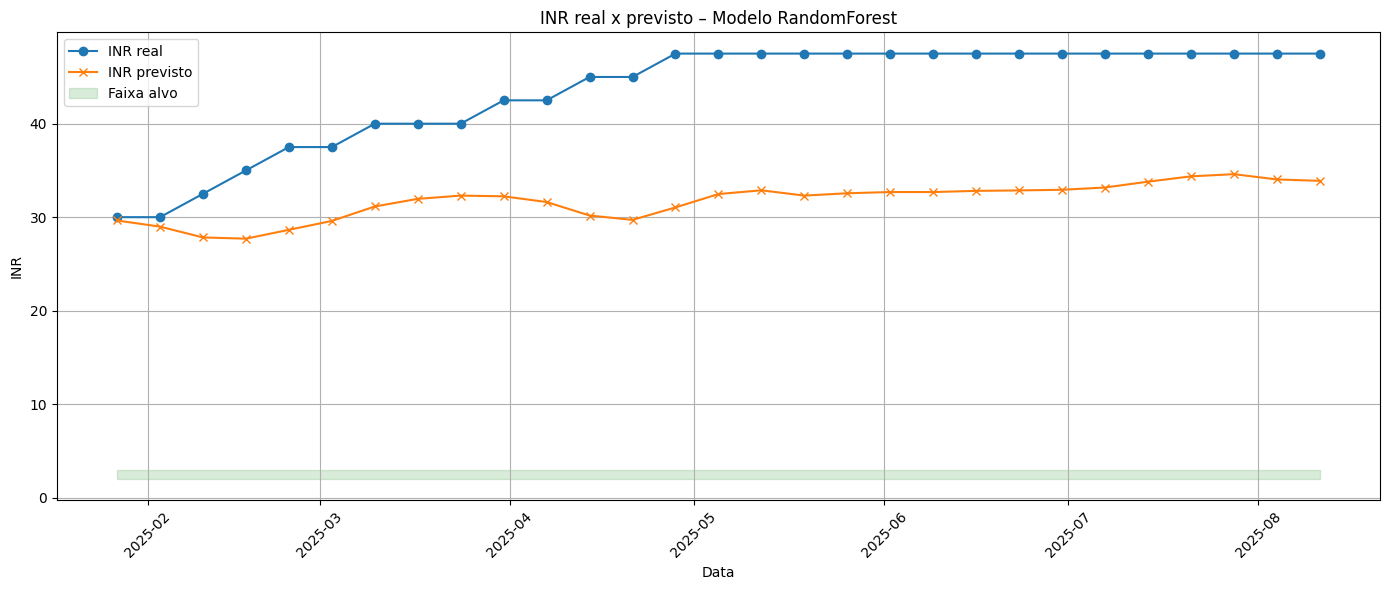

In [56]:
diag.plot_inr_prediction(dates_test1, y_test1.values, y_pred_test1, low_vals1, high_vals1, title="INR real x previsto – Modelo RandomForest")

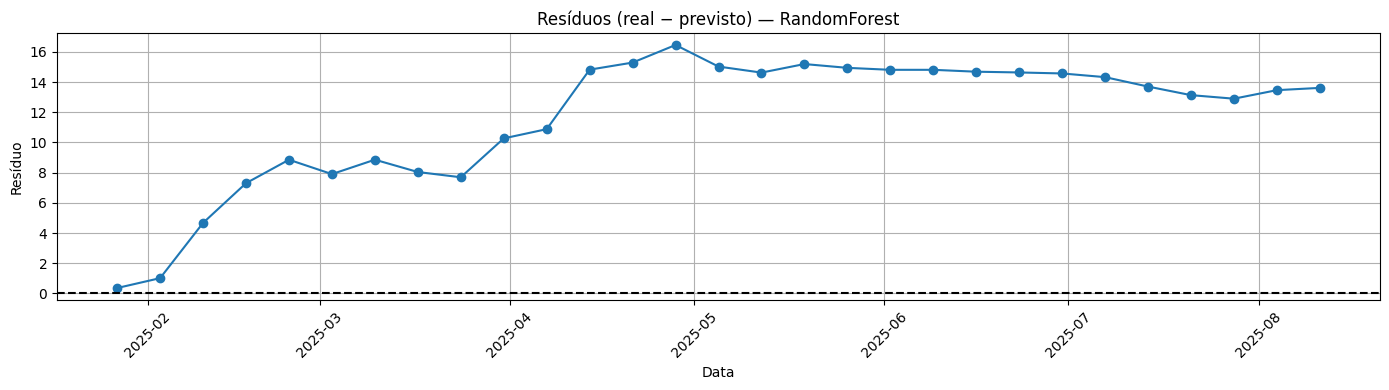

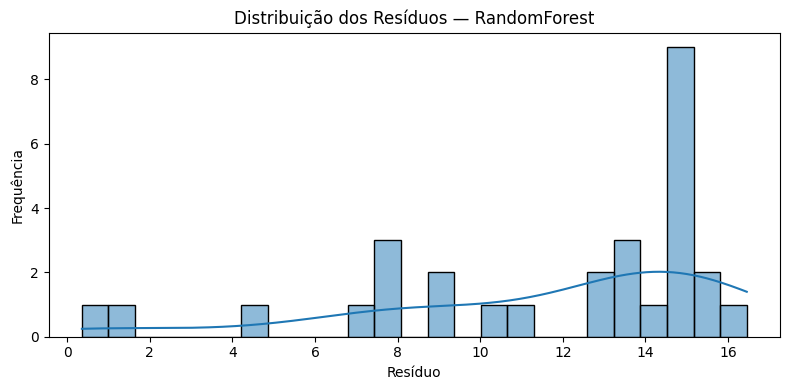

In [57]:
diag.plot_residuals(dates_test1, y_test1.values, y_pred_test1, title="RandomForest")

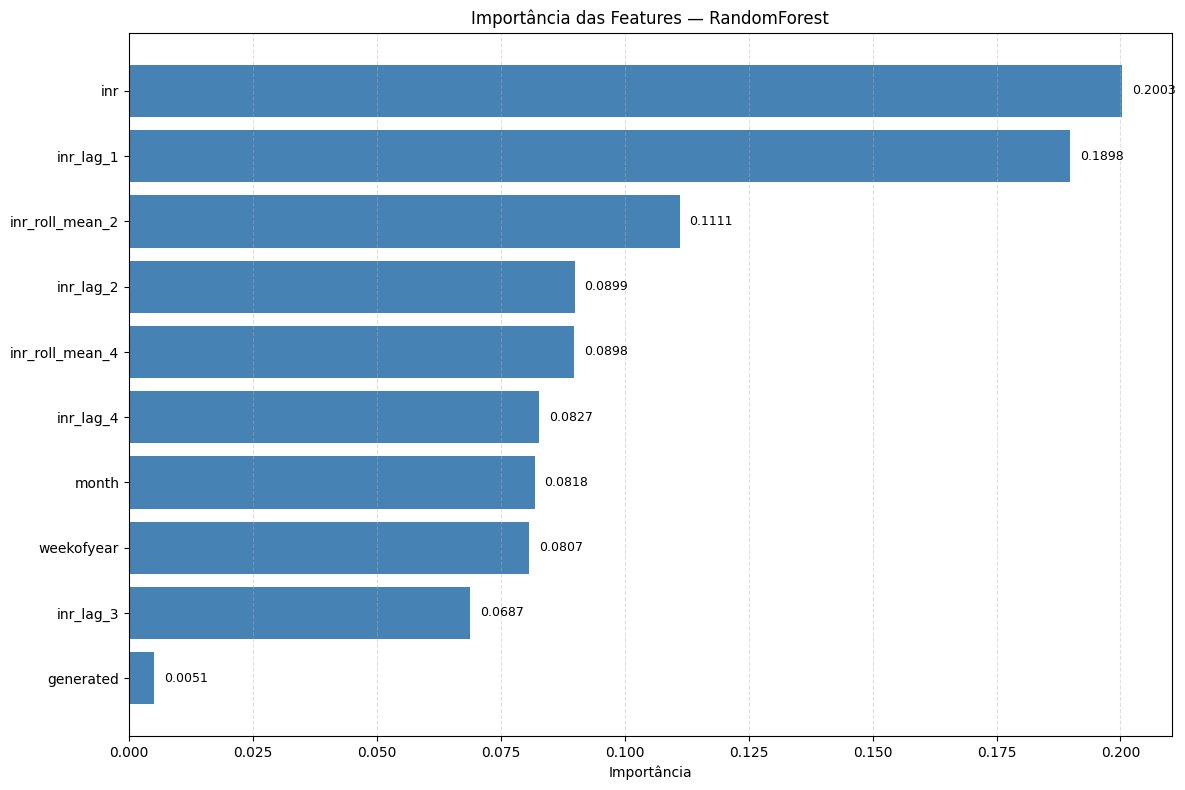

In [58]:
diag.plot_rf_feature_importance(model_rf, features1)

#### Optuna

In [59]:
import optuna
from optuna.samplers import TPESampler
from optuna.pruners import MedianPruner
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score, TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import pandas as pd
import time

# ===== CONFIGURAÇÃO =====
tscv = TimeSeriesSplit(n_splits=5)
RANDOM_STATE = 42

# ===== FUNÇÃO OBJETIVO PARA RANDOM FOREST =====
def objective_rf(trial):
    """
    Função objetivo otimizada para Random Forest com Optuna.
    Inclui todos os principais hiperparâmetros.
    """
    
    # ✅ Espaço de busca otimizado para Random Forest
    param = {
        "random_state": RANDOM_STATE,
        "n_jobs": -1,
        "bootstrap": True,
        "oob_score": True,
        
        # Número de árvores
        "n_estimators": trial.suggest_int("n_estimators", 100, 1000, step=50),
        
        # Profundidade e estrutura
        "max_depth": trial.suggest_categorical("max_depth", [6, 10, 15, 20, None]),
        "max_features": trial.suggest_categorical("max_features", ["sqrt", "log2", 0.3, 0.5, 0.7]),
        
        # Controle de amostragem
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 10),
        
        # Bootstrap sampling
        "max_samples": trial.suggest_categorical("max_samples", [0.6, 0.7, 0.8, 0.9, None]),
        
        # Critério de split
        "criterion": trial.suggest_categorical("criterion", ["squared_error", "absolute_error", "friedman_mse"]),
        
        # Complexidade
        "min_impurity_decrease": trial.suggest_float("min_impurity_decrease", 0.0, 0.01),
        "max_leaf_nodes": trial.suggest_categorical("max_leaf_nodes", [None, 50, 100, 200, 500]),
        
        # Controle adicional
        "ccp_alpha": trial.suggest_float("ccp_alpha", 0.0, 0.01)  # Cost-complexity pruning
    }
    
    # ✅ Cross-validation com TimeSeriesSplit
    model = RandomForestRegressor(**param)
    
    scores = cross_val_score(
        model,
        X_train1,
        y_train1,
        cv=tscv,
        scoring="neg_mean_absolute_error",
        n_jobs=-1
    )
    
    mean_score = float(np.mean(scores))
    std_score = float(np.std(scores))
    
    # ✅ Penalizar alta variância entre folds
    penalty = 0.05 * std_score
    adjusted_score = mean_score - penalty
    
    # Logging
    trial.set_user_attr("mean_score", mean_score)
    trial.set_user_attr("std_score", std_score)
    trial.set_user_attr("cv_scores", scores.tolist())
    
    return adjusted_score



In [60]:
# ===== OTIMIZAÇÃO COM OPTUNA =====
print("=" * 70)
print("🔍 OTIMIZAÇÃO RANDOM FOREST COM OPTUNA")
print("=" * 70)

sampler = TPESampler(
    seed=RANDOM_STATE,
    n_startup_trials=20,  # Mais trials iniciais para RF
    multivariate=True,
    consider_prior=True
)

pruner = MedianPruner(
    n_startup_trials=10,
    n_warmup_steps=2
)

study_rf = optuna.create_study(
    direction="maximize",
    sampler=sampler,
    pruner=pruner,
    study_name="randomforest_optimization"
)

start = time.time()

study_rf.optimize(
    objective_rf,
    n_trials=100,  # 100 trials
    n_jobs=1,  # 1 trial por vez (RF já usa todos os cores internamente)
    show_progress_bar=True,
    timeout=3600  # 1 hora máximo
)

end = time.time()

print(f"\n⏱️ Tempo de otimização: {(end - start)/60:.2f} minutos")
print(f"🎯 Trials completados: {len(study_rf.trials)}")
print(f"🎯 Trials podados: {len([t for t in study_rf.trials if t.state == optuna.trial.TrialState.PRUNED])}")

[I 2026-02-13 06:59:05,377] A new study created in memory with name: randomforest_optimization


🔍 OTIMIZAÇÃO RANDOM FOREST COM OPTUNA


Best trial: 0. Best value: -3.07813:   1%|          | 1/100 [00:00<00:56,  1.74it/s, 0.57/3600 seconds]

[I 2026-02-13 06:59:05,953] Trial 0 finished with value: -3.0781304421358677 and parameters: {'n_estimators': 450, 'max_depth': 6, 'max_features': 'log2', 'min_samples_split': 20, 'min_samples_leaf': 9, 'max_samples': None, 'criterion': 'friedman_mse', 'min_impurity_decrease': 0.0013949386065204184, 'max_leaf_nodes': 200, 'ccp_alpha': 0.005142344384136116}. Best is trial 0 with value: -3.0781304421358677.


Best trial: 0. Best value: -3.07813:   2%|▏         | 2/100 [00:01<01:10,  1.40it/s, 1.39/3600 seconds]

...

[I 2026-02-13 07:03:07,511] Trial 97 finished with value: -2.985691903310862 and parameters: {'n_estimators': 1000, 'max_depth': None, 'max_features': 0.5, 'min_samples_split': 18, 'min_samples_leaf': 10, 'max_samples': 0.6, 'criterion': 'friedman_mse', 'min_impurity_decrease': 0.003068593443322636, 'max_leaf_nodes': 200, 'ccp_alpha': 0.0032692059065371846}. Best is trial 47 with value: -2.8829635854038065.


Best trial: 47. Best value: -2.88296:  99%|█████████▉| 99/100 [04:02<00:01,  1.07s/it, 242.93/3600 seconds]

[I 2026-02-13 07:03:08,309] Trial 98 finished with value: -3.0304156045784554 and parameters: {'n_estimators': 650, 'max_depth': 6, 'max_features': 0.3, 'min_samples_split': 15, 'min_samples_leaf': 9, 'max_samples': 0.8, 'criterion': 'friedman_mse', 'min_impurity_decrease': 0.00681711733301912, 'max_leaf_nodes': 500, 'ccp_alpha': 0.0032104505169723158}. Best is trial 47 with value: -2.8829635854038065.


Best trial: 47. Best value: -2.88296: 100%|██████████| 100/100 [04:04<00:00,  2.44s/it, 244.11/3600 seconds]

[I 2026-02-13 07:03:09,489] Trial 99 finished with value: -2.948570033731164 and parameters: {'n_estimators': 950, 'max_depth': None, 'max_features': 'log2', 'min_samples_split': 13, 'min_samples_leaf': 10, 'max_samples': 0.8, 'criterion': 'friedman_mse', 'min_impurity_decrease': 0.0051899568475185474, 'max_leaf_nodes': 500, 'ccp_alpha': 0.0031979378914698993}. Best is trial 47 with value: -2.8829635854038065.

⏱️ Tempo de otimização: 4.07 minutos
🎯 Trials completados: 100
🎯 Trials podados: 0


In [61]:
# ===== RESULTADOS =====
print("\n" + "=" * 70)
print("✅ MELHORES RESULTADOS")
print("=" * 70)
print(f"📊 Melhor score ajustado: {study_rf.best_value:.4f}")
print(f"📊 MAE médio (CV): {-study_rf.best_trial.user_attrs['mean_score']:.4f}")
print(f"📊 Desvio padrão (CV): {study_rf.best_trial.user_attrs['std_score']:.4f}")

best_params_rf_optuna = study_rf.best_trial.params.copy()
print("\n🎯 Melhores Hiperparâmetros:")
for param, value in sorted(best_params_rf_optuna.items()):
    print(f"  • {param}: {value}")

# ===== IMPORTÂNCIA DOS PARÂMETROS =====
print("\n📈 Importância dos Hiperparâmetros (Top 8):")
try:
    param_importance = optuna.importance.get_param_importances(study_rf)
    for param, importance in sorted(param_importance.items(), key=lambda x: x[1], reverse=True)[:8]:
        print(f"  • {param}: {importance:.4f}")
except:
    print("  (Necessário ≥2 trials)")


✅ MELHORES RESULTADOS
📊 Melhor score ajustado: -2.8830
📊 MAE médio (CV): 2.7718
📊 Desvio padrão (CV): 2.2233

🎯 Melhores Hiperparâmetros:
  • ccp_alpha: 0.006939830580214219
  • criterion: friedman_mse
  • max_depth: 15
  • max_features: sqrt
  • max_leaf_nodes: 50
  • max_samples: 0.6
  • min_impurity_decrease: 0.007380888959468795
  • min_samples_leaf: 10
  • min_samples_split: 10
  • n_estimators: 700

📈 Importância dos Hiperparâmetros (Top 8):
  • min_samples_leaf: 0.4931
  • max_samples: 0.1983
  • max_features: 0.0814
  • min_samples_split: 0.0744
  • criterion: 0.0543
  • min_impurity_decrease: 0.0362
  • max_depth: 0.0281
  • max_leaf_nodes: 0.0145


In [62]:
# ===== TREINAMENTO FINAL =====
print("\n" + "=" * 70)
print("🏋️ TREINAMENTO DO MODELO FINAL")
print("=" * 70)

final_params_rf_optuna = {
    "random_state": RANDOM_STATE,
    "n_jobs": -1,
    "bootstrap": True,
    "oob_score": True,
    "verbose": 1,
    **best_params_rf_optuna
}

model_rf_optuna = RandomForestRegressor(**final_params_rf_optuna)

start_final = time.time()
model_rf_optuna.fit(X_train1, y_train1)
end_final = time.time()

print(f"\n⏱️ Tempo de treinamento final: {(end_final - start_final):.2f} segundos")
print(f"🌳 Total de árvores: {model_rf_optuna.n_estimators}")
if hasattr(model_rf_optuna, 'oob_score_'):
    print(f"📊 OOB Score: {model_rf_optuna.oob_score_:.4f}")
print()


🏋️ TREINAMENTO DO MODELO FINAL


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 176 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 426 tasks      | elapsed:    0.2s
[Parallel(n_jobs=-1)]: Done 700 out of 700 | elapsed:    0.3s finished



⏱️ Tempo de treinamento final: 0.58 segundos
🌳 Total de árvores: 700
📊 OOB Score: 0.4155



In [63]:
# ===== PREVISÕES =====
y_pred_train_rf = model_rf_optuna.predict(X_train1)
y_pred_test_rf = model_rf_optuna.predict(X_test1)

# ===== MÉTRICAS =====
mae_train_rf = mean_absolute_error(y_train1, y_pred_train_rf)
mae_test_rf = mean_absolute_error(y_test1, y_pred_test_rf)
rmse_train_rf = np.sqrt(mean_squared_error(y_train1, y_pred_train_rf))
rmse_test_rf = np.sqrt(mean_squared_error(y_test1, y_pred_test_rf))

mae_gap = ((mae_test_rf - mae_train_rf) / mae_train_rf * 100)
rmse_gap = ((rmse_test_rf - rmse_train_rf) / rmse_train_rf * 100)

print("=" * 70)
print("📊 RESULTADOS FINAIS - RANDOM FOREST (OPTUNA)")
print("=" * 70)
print(f"\n📈 MÉTRICAS FINAIS")
print("-" * 70)
print(f"{'Métrica':<15} {'Train':>12} {'Test':>12} {'Gap':>12}")
print("-" * 70)
print(f"{'MAE':<15} {mae_train_rf:>12.4f} {mae_test_rf:>12.4f} {mae_gap:>11.2f}%")
print(f"{'RMSE':<15} {rmse_train_rf:>12.4f} {rmse_test_rf:>12.4f} {rmse_gap:>11.2f}%")
print("-" * 70)

# Diagnóstico
if mae_gap < 5:
    print("✅ Modelo bem generalizado (gap < 5%)")
elif mae_gap < 10:
    print("⚠️ Leve overfitting (5% < gap < 10%)")
else:
    print("❌ Overfitting significativo (gap > 10%) - Considere aumentar regularização")

# ===== IMPORTÂNCIA DAS FEATURES =====
print("\n" + "=" * 70)
print("📊 IMPORTÂNCIA DAS FEATURES (Top 15)")
print("=" * 70)

feature_importance_rf = pd.DataFrame({
    'feature': X_train1.columns,
    'importance': model_rf_optuna.feature_importances_
}).sort_values('importance', ascending=False)

print(feature_importance_rf.head(15).to_string(index=False))

print("\n" + "=" * 70)
print("🎉 OTIMIZAÇÃO RANDOM FOREST (OPTUNA) CONCLUÍDA!")
print("=" * 70)


📊 RESULTADOS FINAIS - RANDOM FOREST (OPTUNA)

📈 MÉTRICAS FINAIS
----------------------------------------------------------------------
Métrica                Train         Test          Gap
----------------------------------------------------------------------
MAE                   1.7012      10.9287      542.41%
RMSE                  2.1827      11.7451      438.11%
----------------------------------------------------------------------
❌ Overfitting significativo (gap > 10%) - Considere aumentar regularização

📊 IMPORTÂNCIA DAS FEATURES (Top 15)
        feature  importance
            inr    0.219007
      inr_lag_1    0.161760
inr_roll_mean_2    0.138889
      inr_lag_2    0.128064
inr_roll_mean_4    0.117884
      inr_lag_4    0.083384
      inr_lag_3    0.074617
     weekofyear    0.045713
          month    0.027118
      generated    0.003566

🎉 OTIMIZAÇÃO RANDOM FOREST (OPTUNA) CONCLUÍDA!


[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 176 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 426 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 700 out of 700 | elapsed:    0.0s finished
[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 176 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 426 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 700 out of 700 | elapsed:    0.0s finished


### 4. Treinando Regressão Linear

In [64]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import pandas as pd
import time

# ===== CONFIGURAÇÃO =====
RANDOM_STATE = 42

print("=" * 70)
print("📏 REGRESSÃO LINEAR SIMPLES (BASELINE)")
print("=" * 70)

# ===== NORMALIZAÇÃO (IMPORTANTE PARA REGRESSÃO LINEAR) =====
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train1)
X_test_scaled = scaler.transform(X_test1)

# ===== TREINAMENTO =====
start = time.time()

model_lr = LinearRegression(n_jobs=-1)
model_lr.fit(X_train_scaled, y_train1)

end = time.time()

print(f"⏱️ Tempo de treinamento: {(end - start):.4f} segundos")
print(f"📊 Número de features: {X_train1.shape[1]}")
print(f"📊 Número de coeficientes: {len(model_lr.coef_)}")

📏 REGRESSÃO LINEAR SIMPLES (BASELINE)
⏱️ Tempo de treinamento: 0.0010 segundos
📊 Número de features: 10
📊 Número de coeficientes: 10


In [65]:
# ===== PREVISÕES =====
y_pred_train_lr = model_lr.predict(X_train_scaled)
y_pred_test_lr = model_lr.predict(X_test_scaled)

# ===== MÉTRICAS =====
mae_train_lr = mean_absolute_error(y_train1, y_pred_train_lr)
mae_test_lr = mean_absolute_error(y_test1, y_pred_test_lr)
rmse_train_lr = np.sqrt(mean_squared_error(y_train1, y_pred_train_lr))
rmse_test_lr = np.sqrt(mean_squared_error(y_test1, y_pred_test_lr))
r2_train_lr = model_lr.score(X_train_scaled, y_train1)
r2_test_lr = model_lr.score(X_test_scaled, y_test1)

print("\n📈 MÉTRICAS FINAIS")
print("-" * 70)
print(f"{'Métrica':<15} {'Train':>12} {'Test':>12} {'Gap':>12}")
print("-" * 70)
print(f"{'MAE':<15} {mae_train_lr:>12.4f} {mae_test_lr:>12.4f} {((mae_test_lr - mae_train_lr)/mae_train_lr * 100):>11.2f}%")
print(f"{'RMSE':<15} {rmse_train_lr:>12.4f} {rmse_test_lr:>12.4f} {((rmse_test_lr - rmse_train_lr)/rmse_train_lr * 100):>11.2f}%")
print(f"{'R²':<15} {r2_train_lr:>12.4f} {r2_test_lr:>12.4f} {'-':>12}")
print("-" * 70)


📈 MÉTRICAS FINAIS
----------------------------------------------------------------------
Métrica                Train         Test          Gap
----------------------------------------------------------------------
MAE                   2.2155      10.5650      376.86%
RMSE                  2.6253      11.4086      334.56%
R²                    0.3202      -3.0654            -
----------------------------------------------------------------------


In [66]:
# ===== ANÁLISE DE COEFICIENTES =====
print("\n📊 COEFICIENTES MAIS IMPORTANTES (Top 10)")
print("-" * 70)

coef_df = pd.DataFrame({
    'feature': X_train1.columns,
    'coefficient': model_lr.coef_,
    'abs_coefficient': np.abs(model_lr.coef_)
}).sort_values('abs_coefficient', ascending=False)

print(coef_df.head(10)[['feature', 'coefficient']].to_string(index=False))

print(f"\n📍 Intercepto: {model_lr.intercept_:.4f}")
print("=" * 70)


📊 COEFICIENTES MAIS IMPORTANTES (Top 10)
----------------------------------------------------------------------
        feature  coefficient
            inr     1.503335
     weekofyear     0.647756
          month    -0.532096
      inr_lag_4     0.294517
      inr_lag_2     0.238225
      inr_lag_3    -0.199487
      inr_lag_1    -0.085450
inr_roll_mean_2     0.079913
      generated    -0.077558
inr_roll_mean_4     0.069239

📍 Intercepto: 33.0603


### 5. ElasticNet

In [67]:
from sklearn.linear_model import ElasticNet
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import pandas as pd
import time

# ===== CONFIGURAÇÃO =====
tscv = TimeSeriesSplit(n_splits=5)
RANDOM_STATE = 42

# ===== NORMALIZAÇÃO =====
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train1),
    columns=X_train1.columns,
    index=X_train1.index
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test1),
    columns=X_test1.columns,
    index=X_test1.index
)

# ========================================================================
# ETAPA 1: BUSCA DO TIPO DE REGULARIZAÇÃO (L1 vs L2 ratio)
# ========================================================================
print("=" * 70)
print("📍 ETAPA 1: Otimização do Tipo de Regularização (ElasticNet)")
print("=" * 70)

param_grid_stage1 = {
    "alpha": [0.0001, 0.001, 0.01, 0.1, 1.0, 10.0],  # Força da regularização
    "l1_ratio": [0.0, 0.25, 0.5, 0.75, 1.0]  # 0=Ridge, 1=Lasso, 0.5=ElasticNet
}

# Calcular combinações
n_combinations_stage1 = np.prod([len(v) for v in param_grid_stage1.values()])
print(f"🔢 Número de combinações: {n_combinations_stage1}")
print(f"⏱️ Tempo estimado: ~{n_combinations_stage1 * 0.5:.1f} segundos\n")

elasticnet_stage1 = ElasticNet(
    random_state=RANDOM_STATE,
    max_iter=10000,  # Garantir convergência
    tol=1e-4,
    selection='cyclic'
)

grid_stage1 = GridSearchCV(
    estimator=elasticnet_stage1,
    param_grid=param_grid_stage1,
    cv=tscv,
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
    verbose=2,
    return_train_score=True
)

start_stage1 = time.time()
grid_stage1.fit(X_train_scaled, y_train1)
end_stage1 = time.time()

best_params_stage1 = grid_stage1.best_params_
best_score_stage1 = -grid_stage1.best_score_

print("\n" + "=" * 70)
print("✅ RESULTADOS DA ETAPA 1")
print("=" * 70)
print(f"⏱️ Tempo: {(end_stage1 - start_stage1):.2f} segundos")
print(f"📊 Melhor MAE (CV): {best_score_stage1:.4f}\n")
print("🎯 Melhores Parâmetros da Etapa 1:")
for param, value in best_params_stage1.items():
    print(f"  • {param}: {value}")

# Interpretar l1_ratio
l1_ratio = best_params_stage1['l1_ratio']
if l1_ratio == 0.0:
    reg_type = "Ridge (L2 puro)"
elif l1_ratio == 1.0:
    reg_type = "Lasso (L1 puro)"
else:
    reg_type = f"ElasticNet (L1={l1_ratio:.0%}, L2={1-l1_ratio:.0%})"
print(f"📌 Tipo de regularização: {reg_type}\n")

📍 ETAPA 1: Otimização do Tipo de Regularização (ElasticNet)
🔢 Número de combinações: 30
⏱️ Tempo estimado: ~15.0 segundos

Fitting 5 folds for each of 30 candidates, totalling 150 fits

✅ RESULTADOS DA ETAPA 1
⏱️ Tempo: 0.18 segundos
📊 Melhor MAE (CV): 3.0230

🎯 Melhores Parâmetros da Etapa 1:
  • alpha: 10.0
  • l1_ratio: 0.0
📌 Tipo de regularização: Ridge (L2 puro)



In [68]:
# ========================================================================
# ETAPA 2: REFINAMENTO DA FORÇA DE REGULARIZAÇÃO
# ========================================================================
print("=" * 70)
print("📍 ETAPA 2: Refinamento da Força de Regularização")
print("=" * 70)

# Criar grid refinado ao redor do melhor alpha
best_alpha = best_params_stage1['alpha']
alpha_range = np.logspace(
    np.log10(best_alpha * 0.1),
    np.log10(best_alpha * 10),
    num=15
)

param_grid_stage2 = {
    "alpha": alpha_range.tolist(),
    # Testar l1_ratios próximos ao melhor
    "l1_ratio": [
        max(0.0, best_params_stage1['l1_ratio'] - 0.15),
        best_params_stage1['l1_ratio'],
        min(1.0, best_params_stage1['l1_ratio'] + 0.15)
    ]
}

# Calcular combinações
n_combinations_stage2 = np.prod([len(v) for v in param_grid_stage2.values()])
print(f"🔢 Número de combinações: {n_combinations_stage2}")
print(f"⏱️ Tempo estimado: ~{n_combinations_stage2 * 0.5:.1f} segundos\n")

elasticnet_stage2 = ElasticNet(
    random_state=RANDOM_STATE,
    max_iter=10000,
    tol=1e-4,
    selection='random'  # Pode ser mais rápido
)

grid_stage2 = GridSearchCV(
    estimator=elasticnet_stage2,
    param_grid=param_grid_stage2,
    cv=tscv,
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
    verbose=2,
    return_train_score=True
)

start_stage2 = time.time()
grid_stage2.fit(X_train_scaled, y_train1)
end_stage2 = time.time()

best_params_stage2 = grid_stage2.best_params_
best_score_stage2 = -grid_stage2.best_score_

print("\n" + "=" * 70)
print("✅ RESULTADOS DA ETAPA 2")
print("=" * 70)
print(f"⏱️ Tempo: {(end_stage2 - start_stage2):.2f} segundos")
print(f"📊 Melhor MAE (CV): {best_score_stage2:.4f}\n")
print("🎯 Melhores Parâmetros da Etapa 2:")
for param, value in best_params_stage2.items():
    print(f"  • {param}: {value}")
print()

# ========================================================================
# PARÂMETROS FINAIS
# ========================================================================
final_params_elastic = best_params_stage2

print("=" * 70)
print("🎯 PARÂMETROS FINAIS")
print("=" * 70)
for param, value in sorted(final_params_elastic.items()):
    print(f"  • {param}: {value}")

total_time = (end_stage1 - start_stage1 + end_stage2 - start_stage2)
print(f"\n⏱️ Tempo Total de Tuning: {total_time:.2f} segundos")
print(f"📊 Melhoria MAE: {best_score_stage1:.4f} → {best_score_stage2:.4f} ({((best_score_stage2 - best_score_stage1)/best_score_stage1 * 100):+.2f}%)")
print()

📍 ETAPA 2: Refinamento da Força de Regularização
🔢 Número de combinações: 45
⏱️ Tempo estimado: ~22.5 segundos

Fitting 5 folds for each of 45 candidates, totalling 225 fits

✅ RESULTADOS DA ETAPA 2
⏱️ Tempo: 0.35 segundos
📊 Melhor MAE (CV): 2.9310

🎯 Melhores Parâmetros da Etapa 2:
  • alpha: 5.17947467923121
  • l1_ratio: 0.0

🎯 PARÂMETROS FINAIS
  • alpha: 5.17947467923121
  • l1_ratio: 0.0

⏱️ Tempo Total de Tuning: 0.53 segundos
📊 Melhoria MAE: 3.0230 → 2.9310 (-3.04%)



In [69]:
# ========================================================================
# TREINAMENTO FINAL
# ========================================================================
print("=" * 70)
print("🏋️ TREINAMENTO DO MODELO FINAL")
print("=" * 70)

model_elastic = ElasticNet(
    **final_params_elastic,
    random_state=RANDOM_STATE,
    max_iter=10000,
    tol=1e-4
)

start_final = time.time()
model_elastic.fit(X_train_scaled, y_train1)
end_final = time.time()

print(f"⏱️ Tempo de treinamento final: {(end_final - start_final):.4f} segundos")
print(f"🔁 Iterações para convergência: {model_elastic.n_iter_}")
print(f"📊 Features com coef ≠ 0: {np.sum(model_elastic.coef_ != 0)} / {len(model_elastic.coef_)}")
print()

# ===== PREVISÕES =====
y_pred_train_elastic = model_elastic.predict(X_train_scaled)
y_pred_test_elastic = model_elastic.predict(X_test_scaled)

# ===== MÉTRICAS =====
mae_train_elastic = mean_absolute_error(y_train1, y_pred_train_elastic)
mae_test_elastic = mean_absolute_error(y_test1, y_pred_test_elastic)
rmse_train_elastic = np.sqrt(mean_squared_error(y_train1, y_pred_train_elastic))
rmse_test_elastic = np.sqrt(mean_squared_error(y_test1, y_pred_test_elastic))
r2_train_elastic = model_elastic.score(X_train_scaled, y_train1)
r2_test_elastic = model_elastic.score(X_test_scaled, y_test1)

print("=" * 70)
print("📊 RESULTADOS FINAIS - ELASTICNET")
print("=" * 70)
print("\n📈 MÉTRICAS FINAIS")
print("-" * 70)
print(f"{'Métrica':<15} {'Train':>12} {'Test':>12} {'Gap':>12}")
print("-" * 70)
print(f"{'MAE':<15} {mae_train_elastic:>12.4f} {mae_test_elastic:>12.4f} {((mae_test_elastic - mae_train_elastic)/mae_train_elastic * 100):>11.2f}%")
print(f"{'RMSE':<15} {rmse_train_elastic:>12.4f} {rmse_test_elastic:>12.4f} {((rmse_test_elastic - rmse_train_elastic)/rmse_train_elastic * 100):>11.2f}%")
print(f"{'R²':<15} {r2_train_elastic:>12.4f} {r2_test_elastic:>12.4f} {'-':>12}")
print("-" * 70)

# ===== ANÁLISE DE COEFICIENTES =====
print("\n📊 FEATURES MAIS IMPORTANTES (Top 15)")
print("-" * 70)

coef_elastic = pd.DataFrame({
    'feature': X_train_scaled.columns,
    'coefficient': model_elastic.coef_,
    'abs_coefficient': np.abs(model_elastic.coef_)
}).sort_values('abs_coefficient', ascending=False)

print(coef_elastic.head(15)[['feature', 'coefficient']].to_string(index=False))

print(f"\n📌 Features zeradas pela regularização: {np.sum(model_elastic.coef_ == 0)}")
print(f"📍 Intercepto: {model_elastic.intercept_:.4f}")

print("\n" + "=" * 70)
print("🎉 TUNAGEM ELASTICNET CONCLUÍDA!")
print("=" * 70)

🏋️ TREINAMENTO DO MODELO FINAL
⏱️ Tempo de treinamento final: 0.0000 segundos
🔁 Iterações para convergência: 10000
📊 Features com coef ≠ 0: 10 / 10

📊 RESULTADOS FINAIS - ELASTICNET

📈 MÉTRICAS FINAIS
----------------------------------------------------------------------
Métrica                Train         Test          Gap
----------------------------------------------------------------------
MAE                   2.5323      10.8257      327.50%
RMSE                  2.8300      11.7012      313.47%
R²                    0.2100      -3.2767            -
----------------------------------------------------------------------

📊 FEATURES MAIS IMPORTANTES (Top 15)
----------------------------------------------------------------------
        feature  coefficient
            inr     0.197205
      inr_lag_1     0.154407
inr_roll_mean_2     0.143240
inr_roll_mean_4     0.128529
      inr_lag_2     0.122168
      inr_lag_3     0.100465
      inr_lag_4     0.093312
     weekofyear     0.024

#### Optuna

In [70]:
import optuna
from optuna.samplers import TPESampler
from sklearn.linear_model import ElasticNet
from sklearn.model_selection import cross_val_score, TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import pandas as pd
import time

# ===== CONFIGURAÇÃO =====
tscv = TimeSeriesSplit(n_splits=5)
RANDOM_STATE = 42

# ===== NORMALIZAÇÃO =====
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train1),
    columns=X_train1.columns,
    index=X_train1.index
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test1),
    columns=X_test1.columns,
    index=X_test1.index
)

# ===== FUNÇÃO OBJETIVO PARA ELASTICNET =====
def objective_elasticnet(trial):
    """
    Função objetivo para otimização de ElasticNet com Optuna.
    """
    
    # ✅ Espaço de busca otimizado
    param = {
        "alpha": trial.suggest_float("alpha", 1e-5, 10.0, log=True),
        "l1_ratio": trial.suggest_float("l1_ratio", 0.0, 1.0),
        "max_iter": 10000,
        "tol": trial.suggest_float("tol", 1e-5, 1e-3, log=True),
        "selection": trial.suggest_categorical("selection", ["cyclic", "random"]),
        "random_state": RANDOM_STATE
    }
    
    # ✅ Cross-validation
    model = ElasticNet(**param)
    
    scores = cross_val_score(
        model,
        X_train_scaled,
        y_train1,
        cv=tscv,
        scoring="neg_mean_absolute_error",
        n_jobs=-1
    )
    
    mean_score = float(np.mean(scores))
    std_score = float(np.std(scores))
    
    # Penalizar alta variância
    penalty = 0.05 * std_score
    adjusted_score = mean_score - penalty
    
    # Logging
    trial.set_user_attr("mean_score", mean_score)
    trial.set_user_attr("std_score", std_score)
    
    return adjusted_score

In [71]:
# ===== OTIMIZAÇÃO COM OPTUNA =====
print("=" * 70)
print("🔍 OTIMIZAÇÃO ELASTICNET COM OPTUNA")
print("=" * 70)

sampler = TPESampler(
    seed=RANDOM_STATE,
    n_startup_trials=10,
    multivariate=True
)

study_elastic = optuna.create_study(
    direction="maximize",
    sampler=sampler,
    study_name="elasticnet_optimization"
)

start = time.time()

study_elastic.optimize(
    objective_elasticnet,
    n_trials=80,  # 80 trials é suficiente para ElasticNet
    n_jobs=-1,  # ElasticNet é rápido, pode paralelizar
    show_progress_bar=True,
    timeout=600  # 10 minutos máximo
)

end = time.time()

print(f"\n⏱️ Tempo de otimização: {(end - start):.2f} segundos")
print(f"🎯 Trials completados: {len(study_elastic.trials)}")

[I 2026-02-13 07:03:11,711] A new study created in memory with name: elasticnet_optimization


🔍 OTIMIZAÇÃO ELASTICNET COM OPTUNA


Best trial: 1. Best value: -3.12768:   6%|▋         | 5/80 [00:00<00:02, 29.59it/s, 0.12/600 seconds]

[I 2026-02-13 07:03:11,785] Trial 0 finished with value: -3.946777684009587 and parameters: {'alpha': 0.013484386300731347, 'l1_ratio': 0.4404643826524315, 'tol': 6.0409876827568516e-05, 'selection': 'random'}. Best is trial 0 with value: -3.946777684009587.
[I 2026-02-13 07:03:11,808] Trial 2 finished with value: -4.021073721182168 and parameters: {'alpha': 0.0029601366258895593, 'l1_ratio': 0.7841758672595356, 'tol': 0.0009960316962868158, 'selection': 'random'}. Best is trial 0 with value: -3.946777684009587.
[I 2026-02-13 07:03:11,812] Trial 4 finished with value: -3.3485623415020975 and parameters: {'alpha': 7.815619701851843, 'l1_ratio': 0.9618110502887485, 'tol': 7.389245040214558e-05, 'selection': 'cyclic'}. Best is trial 4 with value: -3.3485623415020975.
[I 2026-02-13 07:03:11,812] Trial 1 finished with value: -3.1276766213221725 and parameters: {'alpha': 3.5710906810617047, 'l1_ratio': 0.09805744559301521, 'tol': 1.8586301071930852e-05, 'selection': 'random'}. Best is trial 

[I 2026-02-13 07:03:11,843] Trial 8 finished with value: -3.120986262741818 and parameters: {'alpha': 2.625274137882679, 'l1_ratio': 0.12147656407086893, 'tol': 6.224675147999889e-05, 'selection': 'random'}. Best is trial 8 with value: -3.120986262741818.
[I 2026-02-13 07:03:11,845] Trial 5 finished with value: -3.9171009325899098 and parameters: {'alpha': 0.027779677065419277, 'l1_ratio': 0.7742493958192849, 'tol': 0.0004029968615561776, 'selection': 'cyclic'}. Best is trial 8 with value: -3.120986262741818.


...

[I 2026-02-13 07:03:12,583] Trial 64 finished with value: -3.101185990960006 and parameters: {'alpha': 2.4516422509509668, 'l1_ratio': 0.0072893617747348885, 'tol': 1.6243045090001594e-05, 'selection': 'cyclic'}. Best is trial 60 with value: -3.045070160462449.


Best trial: 60. Best value: -3.04507:  86%|████████▋ | 69/80 [00:00<00:00, 78.67it/s, 0.94/600 seconds]

[I 2026-02-13 07:03:12,600] Trial 65 finished with value: -3.173541908142597 and parameters: {'alpha': 4.853782425310963, 'l1_ratio': 0.09241029964242783, 'tol': 1.7872936759252573e-05, 'selection': 'cyclic'}. Best is trial 60 with value: -3.045070160462449.
[I 2026-02-13 07:03:12,611] Trial 66 finished with value: -3.0981021378662597 and parameters: {'alpha': 2.4717801421798926, 'l1_ratio': 0.10294946536658413, 'tol': 1.463866835084016e-05, 'selection': 'cyclic'}. Best is trial 60 with value: -3.045070160462449.
[I 2026-02-13 07:03:12,627] Trial 67 finished with value: -4.051544554688656 and parameters: {'alpha': 0.0003686177719757822, 'l1_ratio': 0.047141493524429645, 'tol': 0.0009906912251820587, 'selection': 'cyclic'}. Best is trial 60 with value: -3.045070160462449.
[I 2026-02-13 07:03:12,643] Trial 68 finished with value: -4.044985213870055 and parameters: {'alpha': 0.0007033333881186867, 'l1_ratio': 0.24954192304890666, 'tol': 0.0002870033163644243, 'selection': 'random'}. Best 

Best trial: 60. Best value: -3.04507: 100%|██████████| 80/80 [00:00<00:00, 81.72it/s, 0.98/600 seconds]

[I 2026-02-13 07:03:12,658] Trial 69 finished with value: -3.186862768900716 and parameters: {'alpha': 0.6494841030037484, 'l1_ratio': 0.8915193119689655, 'tol': 0.00028992781055164294, 'selection': 'random'}. Best is trial 60 with value: -3.045070160462449.
[I 2026-02-13 07:03:12,674] Trial 73 finished with value: -4.06601172514075 and parameters: {'alpha': 5.439338694231492e-05, 'l1_ratio': 0.5246639447946908, 'tol': 0.00045584797330126657, 'selection': 'random'}. Best is trial 60 with value: -3.045070160462449.
[I 2026-02-13 07:03:12,675] Trial 70 finished with value: -3.129533840942878 and parameters: {'alpha': 5.116381976678544, 'l1_ratio': 0.056406380802310106, 'tol': 1.5767520087776516e-05, 'selection': 'cyclic'}. Best is trial 60 with value: -3.045070160462449.
[I 2026-02-13 07:03:12,675] Trial 72 finished with value: -3.2908618413391255 and parameters: {'alpha': 1.3678291582950632, 'l1_ratio': 0.8080526206964121, 'tol': 0.0007792380291539894, 'selection': 'random'}. Best is tr

In [72]:
# ===== RESULTADOS =====
print("\n" + "=" * 70)
print("✅ MELHORES RESULTADOS")
print("=" * 70)
print(f"📊 Melhor score ajustado: {study_elastic.best_value:.4f}")
print(f"📊 MAE médio (CV): {-study_elastic.best_trial.user_attrs['mean_score']:.4f}")
print(f"📊 Desvio padrão (CV): {study_elastic.best_trial.user_attrs['std_score']:.4f}")

best_params_elastic_optuna = study_elastic.best_trial.params.copy()
print("\n🎯 Melhores Hiperparâmetros:")
for param, value in sorted(best_params_elastic_optuna.items()):
    if param == 'alpha':
        print(f"  • {param}: {value:.6f}")
    elif param == 'tol':
        print(f"  • {param}: {value:.2e}")
    else:
        print(f"  • {param}: {value}")

# Interpretar l1_ratio
l1_ratio = best_params_elastic_optuna['l1_ratio']
if l1_ratio < 0.1:
    reg_type = "Ridge (dominante L2)"
elif l1_ratio > 0.9:
    reg_type = "Lasso (dominante L1)"
else:
    reg_type = f"ElasticNet (L1={l1_ratio:.0%}, L2={1-l1_ratio:.0%})"
print(f"\n📌 Tipo de regularização identificado: {reg_type}")

# ===== IMPORTÂNCIA DOS PARÂMETROS =====
print("\n📈 Importância dos Hiperparâmetros:")
try:
    param_importance = optuna.importance.get_param_importances(study_elastic)
    for param, importance in sorted(param_importance.items(), key=lambda x: x[1], reverse=True):
        print(f"  • {param}: {importance:.4f}")
except:
    print("  (Necessário ≥2 trials)")


✅ MELHORES RESULTADOS
📊 Melhor score ajustado: -3.0451
📊 MAE médio (CV): 2.9336
📊 Desvio padrão (CV): 2.2297

🎯 Melhores Hiperparâmetros:
  • alpha: 5.410723
  • l1_ratio: 0.0016277958559617056
  • selection: cyclic
  • tol: 1.06e-05

📌 Tipo de regularização identificado: Ridge (dominante L2)

📈 Importância dos Hiperparâmetros:
  • alpha: 0.8120
  • l1_ratio: 0.1666
  • tol: 0.0183
  • selection: 0.0031


In [73]:
# ===== TREINAMENTO FINAL =====
print("\n" + "=" * 70)
print("🏋️ TREINAMENTO DO MODELO FINAL")
print("=" * 70)

final_params_elastic_optuna = {
    **best_params_elastic_optuna,
    "random_state": RANDOM_STATE,
    "max_iter": 10000
}

model_elastic_optuna = ElasticNet(**final_params_elastic_optuna)

start_final = time.time()
model_elastic_optuna.fit(X_train_scaled, y_train1)
end_final = time.time()

print(f"⏱️ Tempo de treinamento: {(end_final - start_final):.4f} segundos")
print(f"🔁 Iterações: {model_elastic_optuna.n_iter_}")
print(f"📊 Features não-zero: {np.sum(model_elastic_optuna.coef_ != 0)} / {len(model_elastic_optuna.coef_)}")

# ===== PREVISÕES =====
y_pred_train_opt = model_elastic_optuna.predict(X_train_scaled)
y_pred_test_opt = model_elastic_optuna.predict(X_test_scaled)

# ===== MÉTRICAS =====
mae_train_opt = mean_absolute_error(y_train1, y_pred_train_opt)
mae_test_opt = mean_absolute_error(y_test1, y_pred_test_opt)
rmse_train_opt = np.sqrt(mean_squared_error(y_train1, y_pred_train_opt))
rmse_test_opt = np.sqrt(mean_squared_error(y_test1, y_pred_test_opt))
r2_train_opt = model_elastic_optuna.score(X_train_scaled, y_train1)
r2_test_opt = model_elastic_optuna.score(X_test_scaled, y_test1)

print("\n" + "=" * 70)
print("📊 RESULTADOS FINAIS - ELASTICNET (OPTUNA)")
print("=" * 70)
print("\n📈 MÉTRICAS FINAIS")
print("-" * 70)
print(f"{'Métrica':<15} {'Train':>12} {'Test':>12} {'Gap':>12}")
print("-" * 70)
print(f"{'MAE':<15} {mae_train_opt:>12.4f} {mae_test_opt:>12.4f} {((mae_test_opt - mae_train_opt)/mae_train_opt * 100):>11.2f}%")
print(f"{'RMSE':<15} {rmse_train_opt:>12.4f} {rmse_test_opt:>12.4f} {((rmse_test_opt - rmse_train_opt)/rmse_train_opt * 100):>11.2f}%")
print(f"{'R²':<15} {r2_train_opt:>12.4f} {r2_test_opt:>12.4f} {'-':>12}")
print("-" * 70)

# ===== ANÁLISE DE COEFICIENTES =====
print("\n📊 COEFICIENTES MAIS IMPORTANTES (Top 20)")
print("-" * 70)

coef_optuna = pd.DataFrame({
    'feature': X_train_scaled.columns,
    'coefficient': model_elastic_optuna.coef_,
    'abs_coefficient': np.abs(model_elastic_optuna.coef_)
}).sort_values('abs_coefficient', ascending=False)

# Features com coeficiente não-zero
coef_nonzero = coef_optuna[coef_optuna['coefficient'] != 0]
print(coef_nonzero.head(20)[['feature', 'coefficient']].to_string(index=False))

print(f"\n📌 Total de features selecionadas: {len(coef_nonzero)} / {len(coef_optuna)}")
print(f"📌 Features zeradas: {len(coef_optuna) - len(coef_nonzero)}")
print(f"📍 Intercepto: {model_elastic_optuna.intercept_:.4f}")


🏋️ TREINAMENTO DO MODELO FINAL
⏱️ Tempo de treinamento: 0.0000 segundos
🔁 Iterações: 8
📊 Features não-zero: 9 / 10

📊 RESULTADOS FINAIS - ELASTICNET (OPTUNA)

📈 MÉTRICAS FINAIS
----------------------------------------------------------------------
Métrica                Train         Test          Gap
----------------------------------------------------------------------
MAE                   2.5409      10.8227      325.94%
RMSE                  2.8367      11.7012      312.50%
R²                    0.2063      -3.2766            -
----------------------------------------------------------------------

📊 COEFICIENTES MAIS IMPORTANTES (Top 20)
----------------------------------------------------------------------
        feature  coefficient
            inr     0.191046
      inr_lag_1     0.150292
inr_roll_mean_2     0.139696
inr_roll_mean_4     0.125554
      inr_lag_2     0.119322
      inr_lag_3     0.098243
      inr_lag_4     0.091029
     weekofyear     0.022135
          month

In [ ]:
# ===== SALVAR COEFICIENTES =====
coef_path = "models/elasticnet_optuna_coefficients.csv"
coef_optuna.to_csv(coef_path, index=False)
print(f"\n✅ Coeficientes salvos em: {coef_path}")

print("\n" + "=" * 70)
print("🎉 OTIMIZAÇÃO ELASTICNET (OPTUNA) CONCLUÍDA!")
print("=" * 70)

### Resultados do Paciente 01

In [ ]:
import pandas as pd
import numpy as np
import json
import pickle
import joblib
from datetime import datetime
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# ===== CLASSE PARA GERENCIAR RESULTADOS =====
class ModelResultsManager:
    """
    Gerenciador centralizado de resultados de modelos.
    Salva métricas, parâmetros e permite comparações.
    """
    
    def __init__(self, results_dir="model_results"):
        """
        Inicializa o gerenciador.
        
        Args:
            results_dir: Diretório para salvar resultados
        """
        self.results_dir = Path(results_dir)
        self.results_dir.mkdir(exist_ok=True)
        
        # DataFrame para armazenar todos os resultados
        self.results_df = pd.DataFrame()
        
        # Dicionário para armazenar modelos
        self.models = {}
        
        # Caminho do arquivo de resultados
        self.results_file = self.results_dir / "all_results.csv"
        self.results_json = self.results_dir / "all_results.json"
        
        # Carregar resultados anteriores se existirem
        self._load_existing_results()
    
    def _load_existing_results(self):
        """Carrega resultados salvos anteriormente."""
        if self.results_file.exists():
            self.results_df = pd.read_csv(self.results_file)
            print(f"✅ Resultados anteriores carregados: {len(self.results_df)} modelos")
        else:
            print("📝 Iniciando novo registro de resultados")
    
    def add_result(self, model_name, model, X_train, y_train, X_test, y_test, 
                   best_params=None, cv_score=None, scaler=None, 
                   training_time=None, additional_info=None):
        """
        Adiciona resultado de um modelo.
        
        Args:
            model_name: Nome do modelo (ex: "XGBoost_Optuna")
            model: Modelo treinado
            X_train, y_train: Dados de treino
            X_test, y_test: Dados de teste
            best_params: Melhores hiperparâmetros encontrados
            cv_score: Score de cross-validation
            scaler: Scaler usado (se houver)
            training_time: Tempo de treinamento em segundos
            additional_info: Dicionário com informações extras
        """
        from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
        
        timestamp = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
        
        # Fazer predições
        if scaler is not None:
            X_train_pred = scaler.transform(X_train)
            X_test_pred = scaler.transform(X_test)
        else:
            X_train_pred = X_train
            X_test_pred = X_test
        
        y_pred_train = model.predict(X_train_pred)
        y_pred_test = model.predict(X_test_pred)
        
        # Calcular métricas
        metrics = {
            'model_name': model_name,
            'timestamp': timestamp,
            'mae_train': mean_absolute_error(y_train, y_pred_train),
            'mae_test': mean_absolute_error(y_test, y_pred_test),
            'rmse_train': np.sqrt(mean_squared_error(y_train, y_pred_train)),
            'rmse_test': np.sqrt(mean_squared_error(y_test, y_pred_test)),
            'r2_train': r2_score(y_train, y_pred_train),
            'r2_test': r2_score(y_test, y_pred_test),
            'mape_train': np.mean(np.abs((y_train - y_pred_train) / y_train)) * 100,
            'mape_test': np.mean(np.abs((y_test - y_pred_test) / y_test)) * 100,
            'mae_gap_percent': ((mean_absolute_error(y_test, y_pred_test) - 
                                mean_absolute_error(y_train, y_pred_train)) / 
                               mean_absolute_error(y_train, y_pred_train) * 100),
            'n_train_samples': len(y_train),
            'n_test_samples': len(y_test),
            'n_features': X_train.shape[1],
            'cv_mae': -cv_score if cv_score is not None else None,
            'training_time_seconds': training_time
        }
        
        # Adicionar informações extras
        if additional_info:
            metrics.update(additional_info)
        
        # Adicionar ao DataFrame
        new_row = pd.DataFrame([metrics])
        self.results_df = pd.concat([self.results_df, new_row], ignore_index=True)
        
        # Salvar modelo
        model_id = f"{model_name}_{datetime.now().strftime('%Y%m%d_%H%M%S')}"
        self.models[model_id] = {
            'model': model,
            'scaler': scaler,
            'params': best_params,
            'metrics': metrics
        }
        
        # Salvar modelo em disco
        model_path = self.results_dir / f"{model_id}.pkl"
        joblib.dump({
            'model': model,
            'scaler': scaler,
            'params': best_params,
            'metrics': metrics
        }, model_path)
        
        # Salvar parâmetros em JSON
        if best_params:
            params_path = self.results_dir / f"{model_id}_params.json"
            with open(params_path, 'w') as f:
                # Converter valores numpy para tipos nativos Python
                params_serializable = {k: (v.item() if hasattr(v, 'item') else v) 
                                      for k, v in best_params.items()}
                json.dump(params_serializable, f, indent=4)
        
        print(f"✅ Resultado salvo: {model_name}")
        print(f"   MAE Test: {metrics['mae_test']:.4f}")
        print(f"   R² Test: {metrics['r2_test']:.4f}")
        print(f"   Gap: {metrics['mae_gap_percent']:.2f}%")
        
        # Salvar resultados atualizados
        self._save_results()
        
        return metrics
    
    def _save_results(self):
        """Salva resultados em CSV e JSON."""
        # CSV
        self.results_df.to_csv(self.results_file, index=False)
        
        # JSON
        results_dict = self.results_df.to_dict(orient='records')
        with open(self.results_json, 'w') as f:
            json.dump(results_dict, f, indent=4, default=str)
    
    def get_comparison(self, sort_by='mae_test', ascending=True, top_n=None):
        """
        Retorna DataFrame comparativo de todos os modelos.
        
        Args:
            sort_by: Coluna para ordenar
            ascending: Ordem crescente ou decrescente
            top_n: Limitar aos N melhores modelos
        """
        if self.results_df.empty:
            print("⚠️ Nenhum resultado salvo ainda")
            return None
        
        df = self.results_df.copy()
        df = df.sort_values(by=sort_by, ascending=ascending)
        
        if top_n:
            df = df.head(top_n)
        
        return df
    
    def print_comparison(self, metrics=['mae_test', 'rmse_test', 'r2_test', 'mae_gap_percent'],
                        sort_by='mae_test', top_n=10):
        """
        Imprime tabela comparativa formatada.
        
        Args:
            metrics: Lista de métricas para exibir
            sort_by: Métrica para ordenar
            top_n: Mostrar apenas top N modelos
        """
        df = self.get_comparison(sort_by=sort_by, top_n=top_n)
        
        if df is None:
            return
        
        print("\n" + "=" * 100)
        print("🏆 COMPARAÇÃO DE MODELOS")
        print("=" * 100)
        
        # Selecionar colunas
        display_cols = ['model_name', 'timestamp'] + metrics
        display_cols = [col for col in display_cols if col in df.columns]
        
        df_display = df[display_cols].copy()
        
        # Formatar valores
        for col in df_display.columns:
            if col not in ['model_name', 'timestamp']:
                df_display[col] = df_display[col].apply(lambda x: f"{x:.4f}" if pd.notna(x) else "N/A")
        
        print(df_display.to_string(index=False))
        
        # Destacar melhor modelo
        best_model = df.iloc[0]['model_name']
        best_score = df.iloc[0][sort_by]
        
        print("\n" + "=" * 100)
        print(f"🥇 MELHOR MODELO: {best_model}")
        print(f"📊 {sort_by}: {best_score:.4f}")
        print("=" * 100)
    
    def plot_comparison(self, metric='mae_test', top_n=10, figsize=(12, 6)):
        """
        Plota gráfico comparativo.
        
        Args:
            metric: Métrica para comparar
            top_n: Número de modelos a exibir
            figsize: Tamanho da figura
        """
        import matplotlib.pyplot as plt
        
        df = self.get_comparison(sort_by=metric, top_n=top_n)
        
        if df is None:
            return
        
        fig, ax = plt.subplots(figsize=figsize)
        
        # Gráfico de barras
        bars = ax.barh(df['model_name'], df[metric])
        
        # Colorir melhor modelo
        bars[0].set_color('green')
        
        ax.set_xlabel(metric.upper())
        ax.set_ylabel('Modelo')
        ax.set_title(f'Comparação de Modelos - {metric.upper()}')
        ax.invert_yaxis()
        
        # Adicionar valores nas barras
        for i, (idx, row) in enumerate(df.iterrows()):
            ax.text(row[metric], i, f' {row[metric]:.4f}', 
                   va='center', fontsize=9)
        
        plt.tight_layout()
        plt.savefig(self.results_dir / f'comparison_{metric}.png', dpi=300, bbox_inches='tight')
        plt.show()
        
        print(f"✅ Gráfico salvo em: {self.results_dir / f'comparison_{metric}.png'}")
    
    def export_to_excel(self, filename='model_results.xlsx'):
        """Exporta resultados para Excel com formatação."""
        if self.results_df.empty:
            print("⚠️ Nenhum resultado para exportar")
            return
        
        excel_path = self.results_dir / filename
        
        with pd.ExcelWriter(excel_path, engine='openpyxl') as writer:
            # Aba 1: Todos os resultados
            self.results_df.to_excel(writer, sheet_name='Todos_Modelos', index=False)
            
            # Aba 2: Top 10 por MAE
            top_mae = self.get_comparison(sort_by='mae_test', top_n=10)
            top_mae.to_excel(writer, sheet_name='Top10_MAE', index=False)
            
            # Aba 3: Top 10 por R²
            top_r2 = self.get_comparison(sort_by='r2_test', ascending=False, top_n=10)
            top_r2.to_excel(writer, sheet_name='Top10_R2', index=False)
            
            # Aba 4: Resumo estatístico
            summary = self.results_df[['mae_test', 'rmse_test', 'r2_test', 'mae_gap_percent']].describe()
            summary.to_excel(writer, sheet_name='Estatisticas')
        
        print(f"✅ Resultados exportados para: {excel_path}")
    
    def get_best_model(self, metric='mae_test', return_scaler=False):
        """
        Retorna o melhor modelo salvo.
        
        Args:
            metric: Métrica para determinar o melhor
            return_scaler: Se True, retorna também o scaler
        """
        if self.results_df.empty:
            print("⚠️ Nenhum modelo salvo")
            return None
        
        # Encontrar melhor modelo
        best_idx = self.results_df[metric].idxmin() if 'mae' in metric or 'rmse' in metric else self.results_df[metric].idxmax()
        best_name = self.results_df.loc[best_idx, 'model_name']
        
        # Buscar modelo nos salvos
        for model_id, model_data in self.models.items():
            if best_name in model_id:
                print(f"🏆 Melhor modelo: {best_name}")
                print(f"📊 {metric}: {self.results_df.loc[best_idx, metric]:.4f}")
                
                if return_scaler:
                    return model_data['model'], model_data['scaler']
                return model_data['model']
        
        return None

In [ ]:
# ===== INICIALIZAR GERENCIADOR (EXECUTAR UMA VEZ NO INÍCIO) =====
results_manager = ModelResultsManager(results_dir="model_results")

# ===== EXEMPLO: SALVAR XGBOOST =====
# (Execute após treinar o modelo XGBoost)

results_manager.add_result(
    model_name="XGBoost_Optuna",
    model=model_xgb,
    X_train=X_train1,
    y_train=y_train1,
    X_test=X_test1,
    y_test=y_test1,
    best_params=best_params_xgb,
    cv_score=study_xgb.best_value,
    training_time=end - start,
    additional_info={
        'best_iteration': model_xgb.best_iteration,
        'n_estimators_used': model_xgb.best_iteration,
        'optimization_method': 'Optuna_TPE',
        'n_trials': len(study_xgb.trials)
    }
)

# ===== EXEMPLO: SALVAR LIGHTGBM =====
results_manager.add_result(
    model_name="LightGBM_Optuna",
    model=model_lgb,
    X_train=X_train1,
    y_train=y_train1,
    X_test=X_test1,
    y_test=y_test1,
    best_params=best_params,
    cv_score=study.best_value,
    training_time=end - start,
    additional_info={
        'best_iteration': model_lgb.best_iteration_,
        'optimization_method': 'Optuna_TPE'
    }
)

# ===== EXEMPLO: SALVAR RANDOM FOREST =====
results_manager.add_result(
    model_name="RandomForest_Optuna",
    model=model_rf_optuna,
    X_train=X_train1,
    y_train=y_train1,
    X_test=X_test1,
    y_test=y_test1,
    best_params=best_params_rf_optuna,
    cv_score=study_rf.best_value,
    training_time=end - start,
    additional_info={
        'n_trees': model_rf_optuna.n_estimators,
        'oob_score': model_rf_optuna.oob_score_ if hasattr(model_rf_optuna, 'oob_score_') else None,
        'optimization_method': 'Optuna_TPE'
    }
)

# ===== EXEMPLO: SALVAR ELASTICNET (COM SCALER) =====
results_manager.add_result(
    model_name="ElasticNet_Optuna",
    model=model_elastic_optuna,
    X_train=X_train1,
    y_train=y_train1,
    X_test=X_test1,
    y_test=y_test1,
    best_params=best_params_elastic_optuna,
    cv_score=study_elastic.best_value,
    scaler=scaler,  # ⚠️ IMPORTANTE: Passar o scaler!
    training_time=end - start,
    additional_info={
        'n_iterations': model_elastic_optuna.n_iter_,
        'n_features_nonzero': np.sum(model_elastic_optuna.coef_ != 0),
        'optimization_method': 'Optuna_TPE',
        'regularization_type': 'Ridge' if best_params_elastic_optuna['l1_ratio'] < 0.1 
                                else 'Lasso' if best_params_elastic_optuna['l1_ratio'] > 0.9 
                                else 'ElasticNet'
    }
)

In [ ]:
# ===== COMPARAÇÃO EM TABELA =====
results_manager.print_comparison(
    metrics=['mae_test', 'rmse_test', 'r2_test', 'mae_gap_percent', 'training_time_seconds'],
    sort_by='mae_test',
    top_n=10
)

# ===== COMPARAÇÃO GRÁFICA =====
results_manager.plot_comparison(metric='mae_test', top_n=10)

# ===== EXPORTAR PARA EXCEL =====
results_manager.export_to_excel('comparacao_modelos.xlsx')

# ===== OBTER DATAFRAME PARA ANÁLISE CUSTOMIZADA =====
df_results = results_manager.get_comparison()
print(df_results.head())

# ===== RECUPERAR MELHOR MODELO =====
best_model, best_scaler = results_manager.get_best_model(metric='mae_test', return_scaler=True)

# Fazer predições com o melhor modelo
if best_scaler:
    X_new_scaled = best_scaler.transform(X_new)
    predictions = best_model.predict(X_new_scaled)
else:
    predictions = best_model.predict(X_new)

In [ ]:
import sqlite3
from datetime import datetime

class ModelResultsDB:
    """Versão com banco de dados SQLite."""
    
    def __init__(self, db_path="model_results.db"):
        self.db_path = db_path
        self.conn = sqlite3.connect(db_path)
        self._create_tables()
    
    def _create_tables(self):
        """Cria tabelas se não existirem."""
        cursor = self.conn.cursor()
        
        # Tabela de modelos
        cursor.execute('''
            CREATE TABLE IF NOT EXISTS models (
                id INTEGER PRIMARY KEY AUTOINCREMENT,
                model_name TEXT NOT NULL,
                timestamp DATETIME DEFAULT CURRENT_TIMESTAMP,
                mae_train REAL,
                mae_test REAL,
                rmse_train REAL,
                rmse_test REAL,
                r2_train REAL,
                r2_test REAL,
                mae_gap_percent REAL,
                cv_mae REAL,
                training_time_seconds REAL,
                n_train_samples INTEGER,
                n_test_samples INTEGER,
                n_features INTEGER,
                optimization_method TEXT,
                model_path TEXT,
                params_json TEXT
            )
        ''')
        
        self.conn.commit()
    
    def add_result(self, model_name, metrics, params=None, model_path=None):
        """Adiciona resultado ao banco."""
        cursor = self.conn.cursor()
        
        cursor.execute('''
            INSERT INTO models (
                model_name, mae_train, mae_test, rmse_train, rmse_test,
                r2_train, r2_test, mae_gap_percent, cv_mae, training_time_seconds,
                n_train_samples, n_test_samples, n_features, optimization_method,
                model_path, params_json
            ) VALUES (?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?)
        ''', (
            model_name,
            metrics.get('mae_train'),
            metrics.get('mae_test'),
            metrics.get('rmse_train'),
            metrics.get('rmse_test'),
            metrics.get('r2_train'),
            metrics.get('r2_test'),
            metrics.get('mae_gap_percent'),
            metrics.get('cv_mae'),
            metrics.get('training_time_seconds'),
            metrics.get('n_train_samples'),
            metrics.get('n_test_samples'),
            metrics.get('n_features'),
            metrics.get('optimization_method'),
            model_path,
            json.dumps(params) if params else None
        ))
        
        self.conn.commit()
        print(f"✅ Resultado salvo no banco: {model_name}")
    
    def get_all_results(self):
        """Retorna todos os resultados."""
        return pd.read_sql_query("SELECT * FROM models ORDER BY mae_test ASC", self.conn)
    
    def get_best_model(self, metric='mae_test'):
        """Retorna melhor modelo."""
        order = "ASC" if 'mae' in metric or 'rmse' in metric else "DESC"
        query = f"SELECT * FROM models ORDER BY {metric} {order} LIMIT 1"
        return pd.read_sql_query(query, self.conn)
    
    def close(self):
        """Fecha conexão."""
        self.conn.close()

# ===== USO DO BANCO DE DADOS =====
db = ModelResultsDB("model_results.db")

# Adicionar resultado
db.add_result(
    model_name="XGBoost_Optuna",
    metrics=metrics,
    params=best_params_xgb,
    model_path="models/xgboost_optuna.pkl"
)

# Consultar
df_all = db.get_all_results()
print(df_all)

# Fechar
db.close()

In [ ]:
# Célula 1: Inicializar (uma vez)
results_manager = ModelResultsManager()

# Célula 2: Treinar XGBoost
# ... código de treinamento ...
results_manager.add_result("XGBoost_Optuna", model_xgb, X_train1, y_train1, X_test1, y_test1, best_params_xgb, study_xgb.best_value, training_time=end-start)

# Célula 3: Treinar LightGBM
# ... código de treinamento ...
results_manager.add_result("LightGBM_Optuna", model_lgb, ...)

# Célula 4: Treinar Random Forest
# ... código de treinamento ...
results_manager.add_result("RandomForest_Optuna", model_rf_optuna, ...)

# Célula 5: Comparar tudo
results_manager.print_comparison()
results_manager.plot_comparison()
results_manager.export_to_excel()

## 5. Resultados da análise

In [49]:
def pct_within_range(y_pred, low, high):
    """
    Percentual de predições dentro da faixa [low, high].
    low/high podem ser escalares ou arrays com mesmo comprimento de y_pred.
    Retorna valor em percent (0-100).
    """
    y_pred = np.asarray(y_pred)
    low_arr = np.asarray(low)
    high_arr = np.asarray(high)
    
    if low_arr.shape != y_pred.shape or high_arr.shape != y_pred.shape:
        low_arr = np.full_like(y_pred, low)
        high_arr = np.full_like(y_pred, high)

    within = ((y_pred >= low_arr) & (y_pred <= high_arr)).sum()
    return float(within) / float(len(y_pred)) * 100.0

def avg_distance_to_range(y_pred, low, high):
    """
    Distância média até a faixa [low, high]. Dentro da faixa => 0.
    low/high podem ser escalares ou arrays.
    Retorna float (mesma unidade de y_pred).
    """
    y_pred = np.asarray(y_pred)
    low_arr = np.asarray(low)
    high_arr = np.asarray(high)
    
    if low_arr.shape != y_pred.shape or high_arr.shape != y_pred.shape:
        low_arr = np.full_like(y_pred, low)
        high_arr = np.full_like(y_pred, high)

    dist = np.where(y_pred < low_arr, low_arr - y_pred,
                    np.where(y_pred > high_arr, y_pred - high_arr, 0.0))
    return float(np.mean(dist))

def evaluate_models(models: dict, X_test, y_test, low, high, return_preds=False):
    """
    Avalia múltiplos modelos de regressão em X_test/y_test.
    - models: dict {name: model_object} (modelo deve ter .predict(X))
    - X_test, y_test: arrays ou DataFrame/Series
    - low, high: escalares ou arrays (mesmo tamanho de y_test) com limites alvo
    - return_preds: se True, retorna também dict com predições por modelo
    Retorna: results_df (DataFrame com métricas por modelo), preds_dict (opcional)
    Métricas calculadas: MAE, RMSE, pct_within_range(%), avg_distance_to_range
    """
    results = []
    preds = {}
    X_arr = X_test  # assume compatível com .predict do modelo
    y_arr = np.asarray(y_test)

    for name, model in models.items():
        try:
            y_pred = model.predict(X_arr)
        except Exception as e:
            # tentar converter X_arr para numpy se for DataFrame (algumas APIs exigem)
            try:
                y_pred = model.predict(np.asarray(X_arr))
            except Exception as e2:
                raise RuntimeError(f"Falha ao prever com modelo '{name}': {e}; fallback: {e2}")

        # armazenar predições
        preds[name] = np.asarray(y_pred)

        # métricas clássicas
        # filtrar pares válidos (em caso de NaNs nas previsões)
        mask_valid = ~np.isnan(preds[name])
        if mask_valid.sum() == 0:
            mae = np.nan
            rmse = np.nan
        else:
            # alinhar ground truth (assume que y_test tamanho = preds)
            y_valid = y_arr[mask_valid]
            ypred_valid = preds[name][mask_valid]
            mae = mean_absolute_error(y_valid, ypred_valid)
            rmse = mean_squared_error(y_valid, ypred_valid)

        # métricas da faixa alvo (aceita low/high escalares ou arrays)
        pct_range = pct_within_range(preds[name], low, high)
        avg_dist = avg_distance_to_range(preds[name], low, high)

        results.append({
            "model": name,
            "MAE": mae,
            "RMSE": rmse,
            "%_within_range": pct_range,
            "avg_distance_to_range": avg_dist,
            "n_test": len(y_arr)})

    results_df = pd.DataFrame(results).set_index("model")
    if return_preds:
        return results_df, preds
    return results_df


In [87]:
models = {
     "xgb": model_xgb,
     "lgb": model_lgb,
     "rf": model_rf
 }
results_df, preds = evaluate_models(models, X_test, y_test, low_vals, high_vals, return_preds=True)
display(results_df)

,MAE,RMSE,%_within_range,avg_distance_to_range,n_test
model,,,,,
xgb,0.066430,0.014514,100.0,0.0,24
lgb,0.134245,0.029823,100.0,0.0,24
rf,0.082602,0.021135,100.0,0.0,24


#### Recomendações, em desenvolvimento

In [ ]:
def build_next_week_features(last_row, feature_cols, date_col='test_date', target_col='inr', freq_days=7):
    """
    Constrói um DataFrame (1 linha) com as features necessárias para predizer a próxima semana,
    a partir da última observação (last_row: pd.Series).
    - last_row: pd.Series (última linha observada, com colunas usadas nas features)
    - feature_cols: lista das colunas de entrada que o modelo espera (por ex. ['dose_semanal','inr_lag_1',...])
    - retorna: pd.DataFrame com 1 linha, colunas = feature_cols
    -----------------------------------------
    Observações/assunções:
    - Lags: inr_lag_1 será o inr atual (last_row['inr']), inr_lag_2 será last_row['inr_lag_1'], etc.
      Se alguma lag não existir em last_row (por exemplo você usou menos lags), preenche com NaN -> 0.
    - Rolling: inr_roll_mean_w usa last_row's rolling e o incorpora sem recomputar usando histórico longo.
      Aqui assumimos rolling já presente em last_row como última média deslocada (como no pipeline anterior),
      então copiamos o valor existente. Se não existir, deixa NaN -> preencher depois.
    - Se precisar recalcular rolling usando histórico, passe o DataFrame inteiro e eu dou outra função.
    """
    # garantir série
    if not isinstance(last_row, pd.Series):
        raise ValueError("last_row deve ser uma pd.Series (última linha do dataset do paciente).")
    
    # construir uma linha vazia
    next_dict = {}
    
    # regra: para cada feature:
    for f in feature_cols:
        if f == 'dose_semanal':
            # manter mesma dose atual por default (ajuste só após recomendação)
            next_dict[f] = last_row.get('dose_semanal', np.nan)
            continue
        if f.startswith('inr_lag_'):
            # extrair número do lag
            try:
                lag = int(f.split('_')[-1])
            except:
                lag = None
            if lag is None:
                next_dict[f] = last_row.get(f, np.nan)
                continue
            # inr_lag_1 (próximo passo) deve ser o inr atual
            if lag == 1:
                next_dict[f] = last_row.get('inr', last_row.get('inr_lag_1', np.nan))
            else:
                # inr_lag_2_next = last_row['inr_lag_1'], inr_lag_3_next = last_row['inr_lag_2'], etc.
                prev_name = f'inr_lag_{lag-1}'
                next_dict[f] = last_row.get(prev_name, np.nan)
            continue
        if f.startswith('inr_roll_mean_'):
            # assumimos que a média rolante já foi calculada e está deslocada (shifted) no last_row
            # então copiamos o valor atual (que foi calculado com dados até last_row)
            next_dict[f] = last_row.get(f, np.nan)
            continue
        if f == 'inr_diff':
            # inr_diff para o "próximo" previsto não é conhecido; podemos usar last diff
            next_dict[f] = last_row.get('inr_diff', np.nan)
            continue
        if f == 'generated_flag' or f == 'generated':
            # o próximo ponto ainda não é gerado; marcar 1 se quisermos indicar que é uma previsão (0 default)
            next_dict[f] = 0
            continue
        # features temporais (week/month/day) podem ser inferidas incrementando a data
        if f in ['weekofyear', 'month', 'year', 'dayofweek']:
            # data do próximo ponto:
            last_date = pd.to_datetime(last_row.get(date_col))
            next_date = last_date + pd.Timedelta(days=int(freq_days))
            if f == 'weekofyear':
                next_dict[f] = int(next_date.isocalendar().week)
            elif f == 'month':
                next_dict[f] = int(next_date.month)
            elif f == 'year':
                next_dict[f] = int(next_date.year)
            elif f == 'dayofweek':
                next_dict[f] = int(next_date.weekday())
            continue
        # fallback: se a coluna existe em last_row, copie; senão NaN
        next_dict[f] = last_row.get(f, np.nan)
    
    X_next = pd.DataFrame([next_dict], columns=feature_cols)
    # preencher NaNs razoavelmente (ffill/backfill conforme disponibilidade)
    X_next = X_next.fillna(method='ffill', axis=1).fillna(method='bfill', axis=1).fillna(0)
    return X_next


def recommend_dose_from_prediction(model, X_next, last_dose, low, high,
                                   pct_small=0.10, pct_large=0.15,
                                   warn_threshold=1.0):
    """
    Recebe:
      - model: modelo treinado (ex: XGBRegressor)
      - X_next: pd.DataFrame (1 linha) com features da próxima semana
      - last_dose: último dose_semanal registrado (float)
      - low, high: limites alvo (float)
      - pct_small: 0.10 => 10% (ajuste quando pred diff <= 0.5)
      - pct_large: 0.15 => 15% (ajuste quando pred diff <= 1.0)
      - warn_threshold: se diferença > warn_threshold, sinaliza avaliação clínica
    
    Retorna dicionário com:
      - prediction: valor previsto do INR
      - decision: 'increase'/'decrease'/'none'
      - recommended_pct: percentual (positivo para aumento, negativo para redução)
      - recommended_dose: novo valor da dose_semanal sugerida
      - reason: texto explicativo
      - alert: True/False se diferença > warn_threshold (aconselhar consulta médica)
    """
    if X_next.shape[0] != 1:
        raise ValueError("X_next deve ter exatamente 1 linha.")
    # previsão
    pred = float(model.predict(X_next)[0])
    
    # inicial padrão: sem mudança
    decision = 'none'
    recommended_pct = 0.0
    recommended_dose = float(last_dose)
    alert = False
    reason = "Predição dentro da faixa alvo — sem ajuste recomendado."

    # se dentro da faixa:
    if low <= pred <= high:
        return {
            "prediction": pred,
            "decision": decision,
            "recommended_pct": recommended_pct,
            "recommended_dose": recommended_dose,
            "reason": reason,
            "alert": alert
        }
    
    # se abaixo do mínimo
    if pred < low:
        diff = low - pred
        # tiny deviation: up to 0.5 -> +pct_small
        if diff <= 0.5:
            recommended_pct = pct_small
            decision = 'increase'
            reason = f"Predito {diff:.3f} abaixo do limite inferior ({low}). Recomenda-se aumento conservador de {pct_small*100:.0f}% na dose semanal."
        elif diff <= 1.0:
            recommended_pct = pct_large
            decision = 'increase'
            reason = f"Predito {diff:.3f} abaixo do limite inferior ({low}). Recomenda-se aumento de {pct_large*100:.0f}% na dose semanal."
        else:
            # muito abaixo -> alertar
            recommended_pct = pct_large
            decision = 'increase'
            alert = True
            reason = (f"Predito {diff:.3f} abaixo do limite inferior ({low}). Diferença grande (> {warn_threshold}). "
                      f"Recomenda-se avaliação clínica; sugestão inicial: aumento de {pct_large*100:.0f}% para verificação.")
        # calcular nova dose
        recommended_dose = float(last_dose) * (1.0 + recommended_pct)
        return {
            "prediction": pred,
            "decision": decision,
            "recommended_pct": recommended_pct,
            "recommended_dose": recommended_dose,
            "reason": reason,
            "alert": alert
        }
    
    # se acima do máximo
    if pred > high:
        diff = pred - high
        if diff <= 0.5:
            recommended_pct = -pct_small
            decision = 'decrease'
            reason = f"Predito {diff:.3f} acima do limite superior ({high}). Recomenda-se redução conservadora de {pct_small*100:.0f}% na dose semanal."
        elif diff <= 1.0:
            recommended_pct = -pct_large
            decision = 'decrease'
            reason = f"Predito {diff:.3f} acima do limite superior ({high}). Recomenda-se redução de {pct_large*100:.0f}% na dose semanal."
        else:
            recommended_pct = -pct_large
            decision = 'decrease'
            alert = True
            reason = (f"Predito {diff:.3f} acima do limite superior ({high}). Diferença grande (> {warn_threshold}). "
                      f"Recomenda-se avaliação clínica; sugestão inicial: redução de {pct_large*100:.0f}% para verificação.")
        recommended_dose = float(last_dose) * (1.0 + recommended_pct)
        return {
            "prediction": pred,
            "decision": decision,
            "recommended_pct": recommended_pct,
            "recommended_dose": recommended_dose,
            "reason": reason,
            "alert": alert
        }

In [ ]:
# supondo que você tem:
# - model (XGBoost treinado)
# - feature_cols (lista de features que o modelo usa, na ordem correta)
# - df_features (DataFrame com as features geradas por create_time_features, ordenado por date asc)

# pegar última linha observada do paciente
last_row = df1.iloc[-1]   # pd.Series

# construir features da próxima semana
X_next = build_next_week_features(last_row, feature_cols=fc1, date_col=DATE_COL, target_col=TARGET_COL)

# chamar recomendador
last_dose = float(last_row['dose_semanal'])
low = float(last_row['low_range'])
high = float(last_row['high_range'])

recommendation = recommend_dose_from_prediction(model, X_next, last_dose, low, high,
                                                pct_small=0.10, pct_large=0.15, warn_threshold=1.0)

# mostrar resultado
print("Previsão INR próxima semana:", recommendation['prediction'])
print("Decisão:", recommendation['decision'])
print("Recomendação (%):", f"{recommendation['recommended_pct']*100:.1f}%")
print("Dose semanal atual:", last_dose)
print("Dose semanal sugerida:", round(recommendation['recommended_dose'], 2))
print("Alerta clínico:", recommendation['alert'])
print("Explicação:", recommendation['reason'])

#### Recomendações 2.0

In [ ]:
# ========== Função auxiliar: atualiza lags e rolling a partir de histórico ==========
def _update_lags_and_rolls(feature_cols, history_inr, roll_windows):
    """
    Dado history_inr (lista, último item = inr mais recente observado/predito),
    retorna um dict com chaves 'inr_lag_k' e 'inr_roll_mean_w' preenchidas
    de acordo com feature_cols presentes.
    """
    d = {}
    # identificar lags solicitados nas feature_cols
    lag_cols = [c for c in feature_cols if c.startswith('inr_lag_')]
    # ordenar por lag crescente (inr_lag_1, inr_lag_2, ...)
    lag_nums = sorted([int(c.split('_')[-1]) for c in lag_cols]) if lag_cols else []
    # preencher lags: inr_lag_1 = history_inr[-1], inr_lag_2 = history_inr[-2], ...
    for k in lag_nums:
        idx = -k  # -1 => último, -2 => penúltimo
        if len(history_inr) >= k:
            d[f'inr_lag_{k}'] = float(history_inr[idx])
        else:
            # se não houver histórico suficiente, preencher com NaN (ou 0)
            d[f'inr_lag_{k}'] = float(np.nan)

    # rolling means: inr_roll_mean_w = média dos últimos w valores (sem incluir o valor futuro)
    for w in roll_windows:
        if len(history_inr) >= 1:
            # média dos últimos w valores (ou de todos se menos que w)
            vals = history_inr[-w:] if len(history_inr) >= w else history_inr[:]
            d[f'inr_roll_mean_{w}'] = float(np.mean(vals)) if len(vals) > 0 else float(np.nan)
        else:
            d[f'inr_roll_mean_{w}'] = float(np.nan)

    return d

# ========== Função para construir vetor de features para o próximo passo ==========
def build_feature_vector_next_step(last_date, last_history_inr, last_row, feature_cols,
                                   date_col='test_date', freq_days=7, roll_windows=None):
    """
    Constrói um DataFrame (1 linha) contendo as features que o modelo espera para
    a próxima semana (ou próximo passo com freq_days).
    - last_date: ultima data observada (pd.Timestamp)
    - last_history_inr: lista de floats com histórico de INR (ordem cronológica, último = mais recente)
    - last_row: pd.Series contendo colunas auxiliares (dose_semanal, inr_diff, low_range, high_range, generated, etc.)
    - feature_cols: lista de features que o modelo espera (nomes)
    - roll_windows: lista de janelas rolling já usadas no pipeline (ex: [3,4])
    """
    if roll_windows is None:
        # extrair roll windows que podem existir no feature_cols
        roll_windows = []
        for c in feature_cols:
            if c.startswith('inr_roll_mean_'):
                try:
                    roll_windows.append(int(c.split('_')[-1]))
                except:
                    pass
        roll_windows = sorted(set(roll_windows))

    next_date = pd.to_datetime(last_date) + pd.Timedelta(days=int(freq_days))
    vec = {}

    # preencher features temporais
    if 'weekofyear' in feature_cols:
        vec['weekofyear'] = int(next_date.isocalendar().week)
    if 'month' in feature_cols:
        vec['month'] = int(next_date.month)
    if 'year' in feature_cols:
        vec['year'] = int(next_date.year)
    if 'dayofweek' in feature_cols:
        vec['dayofweek'] = int(next_date.weekday())

    # dose_semanal: por default pegar a última registrada (ajuste será sugerido depois)
    if 'dose_semanal' in feature_cols:
        vec['dose_semanal'] = float(last_row.get('dose_semanal', np.nan))

    # inr_diff: usar último inr_diff (poderia ser estimado, mas mantemos último)
    if 'inr_diff' in feature_cols:
        vec['inr_diff'] = float(last_row.get('inr_diff', 0.0))

    # generated flag: futuro ainda não gerado -> 0
    if 'generated_flag' in feature_cols or 'generated' in feature_cols:
        # detectar qual nome está na lista e preencher
        if 'generated_flag' in feature_cols:
            vec['generated_flag'] = int(0)
        if 'generated' in feature_cols:
            vec['generated'] = int(0)

    # low_range, high_range (copiar do last_row)
    if 'low_range' in feature_cols:
        vec['low_range'] = float(last_row.get('low_range', np.nan))
    if 'high_range' in feature_cols:
        vec['high_range'] = float(last_row.get('high_range', np.nan))

    # atualizar lags e rolling via histórico (history inclui valores reais + previsões já geradas)
    lag_and_roll = _update_lags_and_rolls(feature_cols, last_history_inr, roll_windows)
    vec.update(lag_and_roll)

    # preencher quaisquer outras features que possam simplesmente ser copiadas do last_row
    for f in feature_cols:
        if f in vec:
            continue
        if f in last_row.index:
            vec[f] = last_row.get(f)
        else:
            # valor padrão
            vec[f] = float(np.nan)

    # manter apenas as colunas na ordem feature_cols
    row = {c: vec.get(c, np.nan) for c in feature_cols}
    X_next = pd.DataFrame([row], columns=feature_cols)
    # preencher NaNs com estratégia conservadora: forward/backfill com zeros em último caso
    X_next = X_next.fillna(method='ffill', axis=1).fillna(method='bfill', axis=1).fillna(0)
    return X_next, next_date

# ========== Função principal: previsão multi-step + recomendações ==========
def multi_step_forecast_and_recommend(model, df_features, feature_cols,
                                      horizon=4, freq_days=7,
                                      pct_small=0.10, pct_large=0.15, warn_threshold=1.0,
                                      max_pct_change=0.20):
    """
    Gera previsões multi-step e recomendações de dose para cada passo.
    - model: modelo treinado (XGBRegressor)
    - df_features: DataFrame com histórico (ordenado por data asc), deve conter a última linha observada
    - feature_cols: lista de features que o modelo espera
    - horizon: número de passos (semanas) à frente para prever
    - pct_small / pct_large / warn_threshold / max_pct_change: regras de ajuste
    Retorna DataFrame com colunas:
      ['step','date','prediction','last_dose','recommended_pct','recommended_dose','decision','alert','reason']
    """
    # validações mínimas
    if df_features is None or len(df_features) == 0:
        raise ValueError("df_features vazio.")
    df = df_features.copy().reset_index(drop=True)
    last_row = df.iloc[-1]
    last_date = pd.to_datetime(last_row['test_date'])
    # construir histórico de INR (lista), último = mais recente
    # tomar um histórico razoável (por ex. últimos 12 valores) para calcular rolls; aqui usamos todo o histórico disponível
    history_inr = df['inr'].dropna().astype(float).tolist()
    # assegurar que history_inr[-1] é o valor mais recente (deveria ser)
    if len(history_inr) == 0:
        raise ValueError("Sem histórico de INR válido para construir previsões.")

    # descobrir roll windows que existem entre feature_cols
    roll_windows = sorted({int(c.split('_')[-1]) for c in feature_cols if c.startswith('inr_roll_mean_')})

    rows_out = []
    current_history = history_inr[:]  # copia mutável
    current_last_row = last_row.copy()

    # iterative multi-step
    for step in range(1, horizon + 1):
        # construir features para próximo passo
        X_next, next_date = build_feature_vector_next_step(
            last_date=current_last_row['test_date'] if 'test_date' in current_last_row.index else last_date,
            last_history_inr=current_history,
            last_row=current_last_row,
            feature_cols=feature_cols,
            date_col='test_date',
            freq_days=freq_days,
            roll_windows=roll_windows
        )

        # prever
        pred = float(model.predict(X_next)[0])

        # recomendação baseada na regra
        low = float(current_last_row.get('low_range', np.nan))
        high = float(current_last_row.get('high_range', np.nan))
        # fallback se low/high NaN: usar defaults (opcional)
        if np.isnan(low):
            low = 2.5
        if np.isnan(high):
            high = 3.5

        # cálculo decisão
        decision = 'none'
        recommended_pct = 0.0
        recommended_dose = float(current_last_row.get('dose_semanal', np.nan))
        alert = False
        reason = "Dentro da faixa alvo."

        if low <= pred <= high:
            decision = 'none'
            recommended_pct = 0.0
            recommended_dose = float(current_last_row.get('dose_semanal', np.nan))
            reason = "Previsão dentro da faixa alvo. Sem ajuste."
        elif pred < low:
            diff = low - pred
            if diff <= 0.5:
                recommended_pct = pct_small
                decision = 'increase'
                reason = f"Predito {diff:.3f} abaixo do limite inferior ({low}). Aumentar {pct_small*100:.0f}%."
            elif diff <= 1.0:
                recommended_pct = pct_large
                decision = 'increase'
                reason = f"Predito {diff:.3f} abaixo do limite inferior ({low}). Aumentar {pct_large*100:.0f}%."
            else:
                recommended_pct = pct_large
                decision = 'increase'
                alert = True
                reason = f"Predito {diff:.3f} abaixo do limite inferior ({low}). Diferença grande; avaliar clinicamente. Sugestão: +{pct_large*100:.0f}%."
        else:  # pred > high
            diff = pred - high
            if diff <= 0.5:
                recommended_pct = -pct_small
                decision = 'decrease'
                reason = f"Predito {diff:.3f} acima do limite superior ({high}). Reduzir {pct_small*100:.0f}%."
            elif diff <= 1.0:
                recommended_pct = -pct_large
                decision = 'decrease'
                reason = f"Predito {diff:.3f} acima do limite superior ({high}). Reduzir {pct_large*100:.0f}%."
            else:
                recommended_pct = -pct_large
                decision = 'decrease'
                alert = True
                reason = f"Predito {diff:.3f} acima do limite superior ({high}). Diferença grande; avaliar clinicamente. Sugestão: -{pct_large*100:.0f}%."

        # aplicar clip de segurança (ex: não mais que max_pct_change em magnitude)
        if recommended_pct != 0.0:
            if recommended_pct > 0:
                recommended_pct = min(recommended_pct, max_pct_change)
            else:
                recommended_pct = max(recommended_pct, -max_pct_change)

        last_dose = float(current_last_row.get('dose_semanal', np.nan))
        if np.isnan(last_dose):
            # fallback
            last_dose = 100.0

        recommended_dose = float(last_dose * (1.0 + recommended_pct))

        # armazenar saída do passo
        rows_out.append({
            'step': step,
            'date': pd.to_datetime(next_date),
            'prediction': pred,
            'last_dose': last_dose,
            'recommended_pct': recommended_pct,
            'recommended_dose': recommended_dose,
            'decision': decision,
            'alert': alert,
            'reason': reason,
            'low': low,
            'high': high
        })

        # atualizar histórico e last_row para o próximo passo (autorregressivo)
        current_history.append(pred)   # usar a previsão como novo ponto na história
        # atualizar current_last_row: copy e ajustar valores que mudam para o próximo passo
        # - test_date passa a next_date
        # - dose_semanal: assumir que a dose NÃO foi aplicada automaticamente; mantemos last_dose here.
        #   Se você quiser simular aplicação da recomendação, substitua com recommended_dose.
        current_last_row = current_last_row.copy()
        current_last_row['test_date'] = pd.to_datetime(next_date)
        # manter dose_semanal como última observada para a construção de features; não aplicamos a recomendação automaticamente
        # se quiser simular a aplicação, substitua a linha acima por:
        # current_last_row['dose_semanal'] = recommended_dose
        # atualiza inr (último valor) para permitir construção de lags subsequentemente
        current_last_row['inr'] = pred
        # atualiza inr_diff como pred - anterior real
        prev_inr = current_history[-2] if len(current_history) >= 2 else pred
        current_last_row['inr_diff'] = pred - prev_inr

    # retornar tabela
    out_df = pd.DataFrame(rows_out)
    return out_df

In [ ]:
# ========== Exemplo de uso ==========
# - model: seu XGBoost treinado
# - df_features: DataFrame com histórico, ordenado por date asc, e com colunas usadas no feature_cols
# - feature_cols: lista de features que o modelo espera

# Exemplo:
df_features = df1  # já existente
feature_cols = fc1  # ou a lista que você usou para treinar

# fazer previsão multi-step (ex.: 4 semanas)
out = multi_step_forecast_and_recommend(model, df_features, feature_cols, horizon=4)
display(out)